In [1]:
# Get ELENA
!git clone https://github.com/michelelucente/ELENA.git
%cd ELENA

# Install Python deps for notebooks + examples
# (names follow ELENA’s README; CosmoTransitions is on PyPI)
%pip install -q numpy scipy matplotlib cosmoTransitions NatPy la-forge


Cloning into 'ELENA'...
remote: Enumerating objects: 621, done.
remote: Counting objects: 100% (228/228), done.
remote: Compressing objects: 100% (134/134), done.
remote: Total 621 (delta 166), reused 143 (delta 89), pack-reused 393 (from 1)
Receiving objects: 100% (621/621), 30.17 MiB | 26.38 MiB/s, done.
Resolving deltas: 100% (424/424), done.
/content/ELENA
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 62.2/62.2 kB 2.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 41.7/41.7 kB 2.8 MB/s eta 0:00:00


In [2]:
# Add ELENA/src to the Python path for imports (as suggested by the repo)
import sys, os
sys.path.append(os.path.abspath('src'))

In [3]:
from google.colab import files
uploaded = files.upload()



Saving ah_pot.m to ah_pot.m


In [4]:
#!/usr/bin/env python3
"""
Generic converter from a Mathematica DRalgo-style potential

    V[field_, T_] := expr

to a Python module potential_3d.py with

    def V(phi, T)
    def dV(phi, T)

that is numerically stable and ELENA-compatible.

- Works for ANY thermal potential with one scalar field and temperature T.
- Automatically detects all other symbols as parameters that must be provided
  by get_params(T).

Usage:
  1. Put your Mathematica definition (one line) into INPUT_FILE
     e.g.:
       V[phi_, T_] := (msq*ϕ^2)/2 + (λ*ϕ^4)/4 - ...

  2. Run:
       python generate_potential_generic.py

  3. You get `potential_3d.py`. Open it and implement get_params(T).
"""

import sympy as sp
from pathlib import Path
import re

# You already set this:
INPUT_FILE  = "ah_pot.m"
OUTPUT_FILE = "potential_3d.py"


# ------------------------------------------------------------------
# Helpers: Mathematica → SymPy-friendly string
# ------------------------------------------------------------------

# Common symbol name mappings used by DRalgo / SM / BSM models
MMA_SYMBOL_MAP = {
    # Field aliases (Unicode & escaped forms)
    "ϕ": "phi",
    "φ": "phi",
    "\\[CurlyPhi]": "phi",
    "\\[Phi]": "phi",

    # Lambdas
    "λ": "lam",
    "\\[Lambda]": "lam",
    "\\[Lambda]1H": "lam1H",

    # Mus / renormalisation scales
    "μ3US": "mu3US",
    "\\[Mu]3US": "mu3US",
    "\\[Mu]": "mu",

    # Hypercharges / generic charges / angles
    "Yϕ": "Yphi",
    "\\[Alpha]": "alpha",
    "\\[Beta]": "beta",

    # Standard Mathematica builtins
    "Pi": "pi",
    "Sqrt": "sqrt",
    "Log": "log",
}


def extract_def_line(mathematica_str: str):
    """
    Find the last definition line of the form

        V[field_, T_] := expr

    and return:

        field_name, T_name, rhs_string

    with field_name / T_name stripped of underscores.
    """
    lines_with_def = [ln for ln in mathematica_str.splitlines() if ":=" in ln]
    if not lines_with_def:
        raise ValueError("Could not find ':=' in input file.")

    last = lines_with_def[-1]

    # Extract the part between 'V[' and ']:='
    try:
        inside = last.split("V[", 1)[1].split("]:=", 1)[0]
    except IndexError as e:
        raise ValueError(
            "Could not parse the V[field_, T_] definition line. "
            "Make sure it has the form 'V[phi_, T_] := ...'."
        ) from e

    # Split arguments: e.g. "phi_, T_" -> "phi_", "T_"
    parts = [p.strip() for p in inside.split(",")]
    if len(parts) != 2:
        raise ValueError(
            f"Expected two arguments in V[...], found: {inside!r}"
        )

    field_part, T_part = parts
    field_name = field_part.replace("_", "").strip()
    T_name     = T_part.replace("_", "").strip()

    rhs = last.split(":=", 1)[1].strip()
    return field_name, T_name, rhs


def mathematica_to_sympy(expr: str) -> str:
    """
    Generic textual conversion from Mathematica syntax to something SymPy can parse.
    Handles:
      - greek / escaped letters like ϕ, \\[CurlyPhi], λ, \\[Lambda]1H, μ3US, \\[Mu]3US
      - Pi, Sqrt, Log
      - power ^ to **
      - [ ] to ( )
    Everything else is left untouched so it's model-agnostic.
    """
    # Symbol-level replacements
    for old, new in MMA_SYMBOL_MAP.items():
        expr = expr.replace(old, new)

    # Structural replacements
    expr = expr.replace("^", "**")
    expr = expr.replace("[", "(")
    expr = expr.replace("]", ")")
    return expr


def make_half_powers_safe(expr: sp.Expr) -> sp.Expr:
    """
    Replace half-integer powers x^(n/2) with Abs(x)^(n/2) to avoid complex/NaN
    when x is slightly negative due to numerics.

    This catches things like (msq + lam*phi**2)**(3/2), ( ... )**(1/2), etc.
    """

    def repl_pow(e):
        if isinstance(e, sp.Pow) and isinstance(e.exp, sp.Rational) and e.exp.q == 2:
            # e.base**(m/2)  ->  Abs(e.base)**(m/2)
            return sp.Pow(sp.Abs(e.base), e.exp)
        return e

    return expr.replace(
        lambda e: isinstance(e, sp.Pow)
        and isinstance(e.exp, sp.Rational)
        and e.exp.q == 2,
        repl_pow,
    )


def sympy_to_numpy_code(expr: sp.Expr) -> str:
    """
    Convert SymPy expression to a Python/NumPy-friendly code string.
    - uses sympy.pycode
    - then replaces sqrt/log/pi/Abs with safe NumPy wrappers
    """
    code = sp.pycode(expr)  # e.g. sqrt(...), log(...), pi, Abs(...)

    # sqrt -> _rtabs (numerically safe absolute sqrt)
    code = re.sub(r"\bsqrt\(", "_rtabs(", code)

    # log -> _logsafe (numerically safe log)
    code = re.sub(r"\blog\(", "_logsafe(", code)

    # pi -> np.pi
    code = re.sub(r"\bpi\b", "np.pi", code)

    # Abs -> np.abs
    code = re.sub(r"\bAbs\(", "np.abs(", code)

    return code


# ------------------------------------------------------------------
# Main generator
# ------------------------------------------------------------------

def main():
    # 1. Read Mathematica potential
    src = Path(INPUT_FILE).read_text(encoding="utf-8")

    # Extract field / T names and RHS of the potential
    field_name_raw, T_name_raw, rhs_raw = extract_def_line(src)
    rhs_sympy_like = mathematica_to_sympy(rhs_raw)

    # 2. Build SymPy expression
    # We *canonicalise* the Python interface to use 'phi' and 'T'
    phi, T = sp.symbols("phi T", real=True)

    # Let SymPy create symbols for anything else automatically.
    # Map both the original Mathematica argument names and the
    # canonical names so it works whether rhs uses 'phi' or '\\[CurlyPhi]'.
    local_map = {
        field_name_raw: phi,
        T_name_raw: T,
        "phi": phi,
        "T": T,
        "sqrt": sp.sqrt,
        "log": sp.log,
        "pi": sp.pi,
    }

    V_expr = sp.sympify(rhs_sympy_like, locals=local_map)

    # 2b. Make all half-integer powers sqrt-safe
    V_expr = make_half_powers_safe(V_expr)

    # 3. Find all free parameters (symbols) except phi and T
    free_syms = V_expr.free_symbols
    free_syms = sorted(free_syms, key=lambda s: s.name)
    param_syms = [s for s in free_syms if s not in (phi, T)]

    param_names = [s.name for s in param_syms]
    param_names_str = ", ".join(param_names) if param_names else "(none)"

    # Some light classification (just for the header)
    gauge_like   = [n for n in param_names if n.startswith("g")]
    quartic_like = [n for n in param_names if n.startswith("lam")]
    mass_like    = [n for n in param_names if n.startswith("m") or n.endswith("2")]

    # 4. Convert expression to NumPy-friendly string
    V_numpy = sympy_to_numpy_code(V_expr)

    # 5. Build the potential_3d.py text
    header = f'''"""
Auto-generated potential_3d.py from Mathematica DRalgo output.

Original definition:
    V[{field_name_raw}_, {T_name_raw}_] := ...

Python interface:
    V(phi, T)  — one-field 3D effective potential (thermal or not)
    dV(phi, T) — finite-difference derivative wrt phi

Detected free parameters (besides phi, T):
    {param_names_str}

Rough classification:
    - gauge-like:   {", ".join(gauge_like)   or "none detected"}
    - quartic-like: {", ".join(quartic_like) or "none detected"}
    - mass-like:    {", ".join(mass_like)    or "none detected"}

You MUST implement get_params(T) below to provide numerical values
for these parameters at any given temperature T.

Typical usage in ELENA:
    from potential_3d import V, dV
"""

import numpy as np

# ---------- numerically safe helpers ----------

def _rtabs(x, floor=1e-30):
    \"\"\"sqrt(|x|) with a floor to avoid NaNs from tiny negatives.\"\"\"
    x = np.asarray(x, dtype=float)
    return np.sqrt(np.maximum(np.abs(x), floor))

def _logsafe(x, floor=1e-30):
    \"\"\"log(|x|) with a floor to avoid log(0) / log(negative) issues.\"\"\"
    x = np.asarray(x, dtype=float)
    return np.log(np.maximum(np.abs(x), floor))


def get_params(T):
    \"\"\"
    USER MUST IMPLEMENT.

    Given a temperature T (float), return a dict mapping parameter names to values.
    Required keys:
        {param_names_str}

    Example:
        return dict(msq=..., lam=..., gw=..., gY=..., mu3US=...)
    \"\"\"
    raise NotImplementedError(
        "Implement get_params(T) so that it returns a dict with keys: {param_names_str}"
    )

'''

    # parameter extraction inside V
    if param_names:
        param_extract_lines = [
            f"    {name} = params['{name}']"
            for name in param_names
        ]
    else:
        param_extract_lines = ["    # no extra parameters"]
    param_extract_code = "\n".join(param_extract_lines)

    V_def = f'''
def V(phi, T):
    \"\"\"3D effective potential V(phi, T) translated from Mathematica.\"\"\"
    phi = np.asarray(phi, dtype=float)
    T = float(T)

    params = get_params(T)
{param_extract_code}

    return {V_numpy}
'''

    dV_def = r'''
def dV(phi, T, h_rel=1e-3, h_abs=1e-5):
    """
    Numerical derivative dV/dphi via symmetric finite differences.
    Works for scalar phi or NumPy arrays of phi.
    """
    phi = np.asarray(phi, dtype=float)
    T = float(T)

    h = h_rel * np.maximum(np.abs(phi), 1.0) + h_abs
    return (V(phi + h, T) - V(phi - h, T)) / (2.0 * h)
'''

    out_text = header + V_def + dV_def
    Path(OUTPUT_FILE).write_text(out_text, encoding="utf-8")
    print(f"Wrote {OUTPUT_FILE} with generic V(phi,T) and dV(phi,T).")
    print("Free parameters:", param_names_str)


if __name__ == "__main__":
    main()


Wrote potential_3d.py with generic V(phi,T) and dV(phi,T).
Free parameters: Yphi, g1, lam, msq, mu3US


In [5]:
# patch_potential_dralgo.py
"""
Patch an auto-generated potential_3d.py
so that it becomes calibration-ready against a 4D thermal model.

Main idea
---------
We keep the usual DR backbone

    mu_match = c_match(T) * 2πT
    g3^2(T)  = g(μ_match)^2 * T
    λ3(T)    = λ(μ_match)   * T
    m3^2(T)  = m^2(μ_match) + thermal_mass_LO(T)

but we ADD flexible, temperature-dependent matching corrections:

    delta_m3sq(T)
    delta_lam3(T)
    delta_g3sq(T)
    Zphi(T)
    deltaV(T)
    kappa_mu(T)

so that the final 3D effective potential can be tuned to reproduce the
4D thermal results much more closely, including near nucleation.

What this patch does
--------------------
1) Adds a generic base-parameter injection API:
      set_base_params(...)
2) Adds a generic calibration API:
      set_calibration(...)
3) Replaces get_params(T) with a DR+matched prescription:
      - 1-loop DRalgo-like running in 4D
      - LO DR map
      - temperature-dependent finite shifts
4) Renames the original auto-generated V(phi,T) to _V_core(phi,T)
5) Replaces V(phi,T) by a calibrated wrapper:
      V(phi,T) = _V_core(sqrt(Zphi(T))*phi, T) + deltaV(T)
6) Replaces dV(phi,T) accordingly.

Typical workflow
----------------
After generating and patching potential_3d.py:

    from potential_3d import set_base_params, set_calibration

    set_base_params(
        mu0=500.0,
        g4_mu0=0.54,
        lam4_mu0=1.65e-3,
        Yphi=1.0,
        vev=500.0,
        kappa_mu=1.0,
    )

    set_calibration(
        delta_m3sq=lambda T: ...,
        delta_lam3=lambda T: ...,
        delta_g3sq=lambda T: ...,
        Zphi=lambda T: ...,
        deltaV=lambda T: ...,
        kappa_mu=lambda T: ...,
        c_match=lambda T: 1.0,
    )

Notes
-----

- The most important knobs for nucleation matching are usually:
      delta_m3sq(T), delta_lam3(T), Zphi(T), kappa_mu(T)
- deltaV(T) helps align free-energy differences / thermodynamics.
"""

from pathlib import Path
import re

PATH = Path("potential_3d.py")


def _replace_once(text: str, old: str, new: str) -> str:
    if old not in text:
        raise RuntimeError(f"Could not find expected block starting with: {old[:80]!r}")
    return text.replace(old, new, 1)


def main():
    text = PATH.read_text(encoding="utf-8")

    if "def get_params(T):" not in text:
        raise RuntimeError("Could not find def get_params(T): in potential_3d.py")

    if "def V(phi, T):" not in text:
        raise RuntimeError("Could not find def V(phi, T): in potential_3d.py")

    if "def dV(phi, T" not in text:
        raise RuntimeError("Could not find def dV(phi, T, ...) in potential_3d.py")

    # ------------------------------------------------------------------
    # 1) Replace import block with extended matching/calibration utilities
    # ------------------------------------------------------------------
    old_import = "import numpy as np"

    new_import = r'''
import numpy as np

# ============================================================
# Base parameters + calibration knobs for DR -> matched 3D EFT
# ============================================================

_BASE_PARAMS = {}
_CALIBRATION = {}


def set_base_params(**kwargs):
    """
    Store temperature-independent UV / reference inputs used by get_params(T).

    Typical keys
    ------------
    mu0          : reference 4D renormalization scale where inputs are defined
    g4_mu0       : g(mu0)
    lam4_mu0     : lambda(mu0)
    Yphi         : scalar charge
    vev          : v; if m0sq_mu0 not given, uses m^2(mu0) = -lambda(mu0)*v^2
    m0sq_mu0     : m^2(mu0) directly (overrides vev-derived value)
    kappa_mu     : default kappa in mu3US = kappa * g(mu_match) * T
    c_match      : default multiplicative factor in mu_match = c_match * 2*pi*T
    delta_m3sq   : default constant finite shift (if no calibration callable set)
    delta_lam3   : default constant finite shift (if no calibration callable set)
    delta_g3sq   : default constant finite shift (if no calibration callable set)
    Zphi         : default constant field renormalization
    deltaV       : default constant additive free-energy shift
    rge_nsteps   : RGE integration steps
    rge_method   : "euler" or "rk2"
    """
    _BASE_PARAMS.update(kwargs)


def set_calibration(**kwargs):
    """
    Store temperature-dependent calibration functions or constants.

    Supported keys
    --------------
    delta_m3sq : scalar or callable(T)
    delta_lam3 : scalar or callable(T)
    delta_g3sq : scalar or callable(T)
    Zphi       : scalar or callable(T)
    deltaV     : scalar or callable(T)
    kappa_mu   : scalar or callable(T)
    c_match    : scalar or callable(T)

    Example
    -------
    set_calibration(
        delta_m3sq=lambda T: a0 + a1*T + a2*T*T,
        delta_lam3=lambda T: b0 + b1*T,
        Zphi=lambda T: 1.0 + z1/T,
        deltaV=lambda T: v0*T**4,
    )
    """
    _CALIBRATION.update(kwargs)


def clear_calibration():
    """Remove all temperature-dependent calibration settings."""
    _CALIBRATION.clear()


def _eval_maybe_callable(obj, T, default=0.0):
    """
    Evaluate calibration quantity.
    Accepts:
      - None          -> default
      - scalar        -> scalar
      - callable(T)   -> value
    """
    if obj is None:
        return float(default)
    if callable(obj):
        return float(obj(float(T)))
    return float(obj)


def _get_cal(name, T, default=0.0):
    """
    Read calibration quantity, preferring _CALIBRATION over _BASE_PARAMS.
    """
    if name in _CALIBRATION:
        return _eval_maybe_callable(_CALIBRATION[name], T, default)
    return _eval_maybe_callable(_BASE_PARAMS.get(name, None), T, default)


# ==========================================
# 1-loop DRalgo-like 4D RG running utilities
# ==========================================

def _betas_4d_dralgo(g, lam, m2, Y):
    """
    1-loop DRalgo-like beta functions with t = ln(mu).

    d(g^2)/dt = g^4 Y^2 / (24 pi^2)
    dlam/dt   = (3 g^4 Y^4 - 6 g^2 Y^2 lam + 10 lam^2) / (8 pi^2)
    dm2/dt    = m2 (3 g^2 Y^2 - 4 lam) / (8 pi^2)

    Converted to dg/dt:
        dg/dt = g^3 Y^2 / (48 pi^2)
    """
    pi2 = np.pi**2

    beta_g = (g**3 * Y**2) / (48.0 * pi2)

    beta_lam = (
        3.0 * g**4 * Y**4
        - 6.0 * g**2 * Y**2 * lam
        + 10.0 * lam**2
    ) / (8.0 * pi2)

    beta_m2 = (m2 * (3.0 * g**2 * Y**2 - 4.0 * lam)) / (8.0 * pi2)

    return beta_g, beta_lam, beta_m2


def _rge_run_1loop(mu_target, mu0, g0, lam0, m20, Y=1.0, nsteps=400, method="rk2"):
    """
    Run (g, lam, m2) from mu0 -> mu_target using the 1-loop 4D betas.
    Integrates in t = ln(mu).
    """
    mu0 = float(mu0)
    mu_target = float(mu_target)

    if mu0 <= 0.0 or mu_target <= 0.0 or mu_target == mu0:
        return float(g0), float(lam0), float(m20)

    t0 = np.log(mu0)
    t1 = np.log(mu_target)
    ts = np.linspace(t0, t1, int(max(2, nsteps)))

    g = float(g0)
    lam = float(lam0)
    m2 = float(m20)
    Y = float(Y)

    for i in range(len(ts) - 1):
        dt = ts[i + 1] - ts[i]

        if method == "euler":
            bg, bl, bm = _betas_4d_dralgo(g, lam, m2, Y)
            g   = g   + bg * dt
            lam = lam + bl * dt
            m2  = m2  + bm * dt
        else:
            bg1, bl1, bm1 = _betas_4d_dralgo(g, lam, m2, Y)

            g_mid   = g   + 0.5 * bg1 * dt
            lam_mid = lam + 0.5 * bl1 * dt
            m2_mid  = m2  + 0.5 * bm1 * dt

            bg2, bl2, bm2 = _betas_4d_dralgo(g_mid, lam_mid, m2_mid, Y)

            g   = g   + bg2 * dt
            lam = lam + bl2 * dt
            m2  = m2  + bm2 * dt

    return float(g), float(lam), float(m2)


# ==================================
# Calibration helpers used by V / dV
# ==================================

def _sqrt_pos(x, floor=1e-30):
    x = float(x)
    return np.sqrt(max(x, floor))

def _Zphi(T):
    # field renormalization / field-space alignment to 4D
    return max(_get_cal("Zphi", T, 1.0), 1e-12)

def _deltaV(T):
    # additive free-energy shift, useful for thermodynamics alignment
    return _get_cal("deltaV", T, 0.0)
'''

    if "set_base_params" not in text:
        text = _replace_once(text, old_import, new_import)

    # ------------------------------------------------------------------
    # 2) Replace get_params(T)
    # ------------------------------------------------------------------
    start = text.index("def get_params(T):")
    end = text.index("def V(phi, T):", start)

    new_get_params = r'''
def get_params(T):
    """
    Matched 3D parameter map with:
      - 1-loop 4D running
      - LO DR matching
      - temperature-dependent finite calibration shifts

    Core map
    --------
    mu_match = c_match(T) * 2*pi*T      for T > 0
    g3^2     = g(mu_match)^2 * T        + delta_g3sq(T)
    lam3     = lam(mu_match) * T        + delta_lam3(T)
    m3^2     = m^2(mu_match)
               + (T^2/12)*(3 g(mu_match)^2 Y^2 + 4 lam(mu_match))
               + delta_m3sq(T)

    mu3US    = kappa_mu(T) * g(mu_match) * T

    Returns dict keys required by the auto-generated core potential:
      Yphi, g1, lam, msq, mu3US
    """
    T = float(T)

    # -------- base 4D inputs at mu0 --------
    mu0  = float(_BASE_PARAMS.get("mu0", 1.0))
    g0   = float(_BASE_PARAMS.get("g4_mu0", 0.54))
    lam0 = float(_BASE_PARAMS.get("lam4_mu0", 1.65e-3))
    Yphi = float(_BASE_PARAMS.get("Yphi", 1.0))

    m0sq_in = _BASE_PARAMS.get("m0sq_mu0", None)
    if m0sq_in is None:
        vev = float(_BASE_PARAMS.get("vev", 500.0))
        m2_0 = -lam0 * vev**2
    else:
        m2_0 = float(m0sq_in)

    nsteps = int(_BASE_PARAMS.get("rge_nsteps", 400))
    method = str(_BASE_PARAMS.get("rge_method", "rk2")).lower()

    # -------- temperature-dependent matching-scale knob --------
    c_match = max(_get_cal("c_match", T, 1.0), 1e-12)
    mu_match = (c_match * 2.0 * np.pi * T) if (T > 0.0) else mu0

    # -------- run 4D couplings to matching scale --------
    g_match, lam_match, m2_match = _rge_run_1loop(
        mu_target=mu_match,
        mu0=mu0,
        g0=g0,
        lam0=lam0,
        m20=m2_0,
        Y=Yphi,
        nsteps=nsteps,
        method=method,
    )

    # -------- LO DR map --------
    g3sq_lo = (g_match**2) * T
    lam3_lo = lam_match * T
    msq3_lo = m2_match + (T*T / 12.0) * (
        3.0 * (g_match**2) * (Yphi**2) + 4.0 * lam_match
    )

    # -------- temperature-dependent finite shifts --------
    delta_g3sq = _get_cal("delta_g3sq", T, 0.0)
    delta_lam3 = _get_cal("delta_lam3", T, 0.0)
    delta_m3sq = _get_cal("delta_m3sq", T, 0.0)

    g3sq = g3sq_lo + delta_g3sq
    lam3 = lam3_lo + delta_lam3
    msq3 = msq3_lo + delta_m3sq

    # protect from unphysical numerical issues
    g3sq = max(g3sq, 0.0)

    # For lam3, do NOT clip hard to zero unless you explicitly want to.
    # Small negative fitted values can sometimes appear in aggressive matching,
    # but if they destabilize numerics you can enforce positivity externally.
    lam3 = float(lam3)
    msq3 = float(msq3)

    # -------- 3D soft renormalization scale --------
    kappa_mu = max(_get_cal("kappa_mu", T, _BASE_PARAMS.get("kappa_mu", 1.0)), 1e-12)
    mu3US = max(kappa_mu * max(g_match, 1e-12) * max(T, 1e-12), 1e-12)

    return dict(
        Yphi=Yphi,
        g1=np.sqrt(g3sq),   # core potential expects g1, not g1^2
        lam=lam3,
        msq=msq3,
        mu3US=mu3US,
    )
'''

    text = text[:start] + new_get_params + "\n\n" + text[end:]

    # ------------------------------------------------------------------
    # 3) Rename original V -> _V_core
    # ------------------------------------------------------------------
    text = _replace_once(text, "def V(phi, T):", "def _V_core(phi, T):")

    # ------------------------------------------------------------------
    # 4) Replace original dV block with calibrated V and dV
    # ------------------------------------------------------------------
    dV_start = text.index("def dV(phi, T")
    dV_block = text[dV_start:]

    new_V_and_dV = r'''
def V(phi, T):
    """
    Calibrated 3D effective potential.

    The core auto-generated potential is evaluated at a rescaled field
        phi_core = sqrt(Zphi(T)) * phi
    and then shifted by deltaV(T):

        V(phi,T) = _V_core(phi_core, T) + deltaV(T)

    Why this helps:
    - Zphi(T) aligns field-space locations of minima / barrier with the 4D model
    - deltaV(T) aligns free-energy differences and thermodynamics
    """
    phi = np.asarray(phi, dtype=float)
    T = float(T)

    zphi = _Zphi(T)
    phi_core = _sqrt_pos(zphi) * phi

    return _V_core(phi_core, T) + _deltaV(T)


def dV(phi, T, h_rel=1e-3, h_abs=1e-5):
    """
    Numerical derivative of the calibrated potential wrt the external field phi.
    """
    phi = np.asarray(phi, dtype=float)
    T = float(T)

    h = h_rel * np.maximum(np.abs(phi), 1.0) + h_abs
    return (V(phi + h, T) - V(phi - h, T)) / (2.0 * h)
'''

    text = text[:dV_start] + new_V_and_dV

    # ------------------------------------------------------------------
    # 5) Write patched file
    # ------------------------------------------------------------------
    PATH.write_text(text, encoding="utf-8")
    print("Patched potential_3d.py with matched DR calibration support.")
    print("Added knobs: delta_m3sq(T), delta_lam3(T), delta_g3sq(T), Zphi(T), deltaV(T), kappa_mu(T), c_match(T).")


if __name__ == "__main__":
    main()

Patched potential_3d.py with matched DR calibration support.
Added knobs: delta_m3sq(T), delta_lam3(T), delta_g3sq(T), Zphi(T), deltaV(T), kappa_mu(T), c_match(T).


In [6]:

import re
from pathlib import Path

path = Path("potential_3d.py")
text = path.read_text()

# Remove all math. prefixes
text = text.replace("math._rtabs", "_rtabs")
text = text.replace("math._logsafe", "_logsafe")
text = text.replace("math.np.pi", "np.pi")
text = text.replace("math.", "")   # remove any leftover math.

# Clean accidental double prefixes
text = text.replace("np.np", "np")

# Write cleaned file
path.write_text(text)



15156

In [54]:
%%writefile custom_model.py
import numpy as np
import potential_3d
from potential_3d import (
    V as V3_raw,
    dV as dV3_raw,
    set_base_params,
)

HAS_CAL = hasattr(potential_3d, "set_calibration")
if HAS_CAL:
    from potential_3d import set_calibration


class CustomModel:
    def __init__(
        self,
        vev,
        lambda_,
        g,
        xstep,
        Tstep,
        units="MeV",
        Yphi=1.0,
        mu0=None,
        kappa_mu=1.0,
        delta_m3sq=0.0,
        delta_lam3=0.0,
        delta_g3sq=0.0,
        Zphi=1.0,
        deltaV=0.0,
        c_match=1.0,
        rge_nsteps=500,
        rge_method="rk2",
        use_calibration=True,
        subtract_origin=True,
        phi_eps_origin=1e-4,
    ):
        self.vev = float(vev)
        self.lambda_ = float(lambda_)
        self.g = float(g)
        self.Yphi = float(Yphi)
        self.xstep = float(xstep)
        self.Tstep = float(Tstep)
        self.units = units

        self.mu0 = float(mu0) if mu0 is not None else float(vev)

        self.kappa_mu = kappa_mu
        self.delta_m3sq = delta_m3sq
        self.delta_lam3 = delta_lam3
        self.delta_g3sq = delta_g3sq
        self.Zphi = Zphi
        self.deltaV = deltaV
        self.c_match = c_match
        self.rge_nsteps = int(rge_nsteps)
        self.rge_method = str(rge_method).lower()

        self.use_calibration = bool(use_calibration)
        self.subtract_origin = bool(subtract_origin)
        self.phi_eps_origin = float(phi_eps_origin)

        # ----------------------------
        # Base DR / matching parameters
        # ----------------------------
        set_base_params(
            mu0=self.mu0,
            g4_mu0=self.g,
            lam4_mu0=self.lambda_,
            Yphi=self.Yphi,
            vev=self.vev,
            kappa_mu=1.0 if callable(self.kappa_mu) else float(self.kappa_mu),
            delta_m3sq=0.0 if callable(self.delta_m3sq) else float(self.delta_m3sq),
            delta_lam3=0.0 if callable(self.delta_lam3) else float(self.delta_lam3),
            delta_g3sq=0.0 if callable(self.delta_g3sq) else float(self.delta_g3sq),
            Zphi=1.0 if callable(self.Zphi) else float(self.Zphi),
            deltaV=0.0 if callable(self.deltaV) else float(self.deltaV),
            c_match=1.0 if callable(self.c_match) else float(self.c_match),
            rge_nsteps=self.rge_nsteps,
            rge_method=self.rge_method,
        )

        # ----------------------------
        # Optional temperature-dependent calibration
        # ----------------------------
        if self.use_calibration and HAS_CAL:
            set_calibration(
                delta_m3sq=self.delta_m3sq,
                delta_lam3=self.delta_lam3,
                delta_g3sq=self.delta_g3sq,
                Zphi=self.Zphi,
                deltaV=self.deltaV,
                kappa_mu=self.kappa_mu,
                c_match=self.c_match,
            )

        # Exposed potential / derivative
        self.DVtot = lambda phi, T: self._V(phi, T)
        self.gradV = lambda phi, T: self._dV(phi, T)

    # ---------- safe origin subtraction ----------
    def safe_V3_origin(self, T, phi_eps=None):
        if phi_eps is None:
            phi_eps = self.phi_eps_origin

        vals = [
            V3_raw(+phi_eps, T),
            V3_raw(-phi_eps, T),
            V3_raw(2.0 * phi_eps, T),
            V3_raw(-2.0 * phi_eps, T),
        ]
        vals = np.asarray(vals, dtype=float)
        vals = vals[np.isfinite(vals)]

        if len(vals) == 0:
            return np.nan

        return np.mean(vals)

    def _V(self, phi, T):
        val = V3_raw(phi, T)

        if not self.subtract_origin:
            return val

        V0 = self.safe_V3_origin(T)
        if not np.isfinite(V0):
            return val

        return val - V0

    def _dV(self, phi, T):
        return dV3_raw(phi, T)

    def get_param_dict(self, T):
        return potential_3d.get_params(T)

Overwriting custom_model.py


In [55]:
import sys
import importlib

# reload custom_model if already imported
if "custom_model" in sys.modules:
    importlib.reload(sys.modules["custom_model"])

from custom_model import CustomModel

In [96]:
# test_driver.py
import numpy as np
from utils import convert_units
from custom_model import CustomModel

units = np.random.choice(list(convert_units.keys()))

lambda_ = 6e-3
g = 0.75002
Yphi = 1.0
vev, units = 500.0, "MeV"
description = "3D BP2"

dp = CustomModel(
    vev=vev,
    lambda_=lambda_,
    g=g,
    xstep=0.5,
    Tstep=0.5,
    units=units,
    Yphi=Yphi,
    mu0=vev,
    kappa_mu=lambda T: 1.0,
    delta_m3sq=lambda T: 0.0,
    delta_lam3=lambda T: 0.002 * T,   # trial positive quartic shift
    delta_g3sq=lambda T: 0.0,
    Zphi=lambda T: 1.8,               # trial field rescaling
    deltaV=lambda T: 0.0,
    c_match=lambda T: 1.0,
    rge_nsteps=500,
    rge_method="rk2",
    use_calibration=True,
    subtract_origin=True,
    phi_eps_origin=1e-4,
)

V = dp.DVtot
dV = dp.gradV

phi_test = 10.0
T_test = 200.0

print(f"description = {description}")
print(f"units       = {units}")
print(f"V_raw(10,T) = {dp._V(phi_test, T_test)}")
print(f"dV(10,T)    = {dV(phi_test, T_test)}")
print(f"V(0,T)      = {V(0.0, T_test)}")
print(f"V(vev,T)    = {V(vev, T_test)}")

print("\nMatched parameters at T_test:")
print(dp.get_param_dict(T_test))

description = 3D BP2
units       = MeV
V_raw(10,T) = 277826.10159336997
dV(10,T)    = 48293.329084627694
V(0,T)      = nan
V(vev,T)    = 170806500402.40698

Matched parameters at T_test:
{'Yphi': 1.0, 'g1': np.float64(10.618510877789392), 'lam': 3.734535998306044, 'msq': 4330.880283674794, 'mu3US': 150.16842095575998}


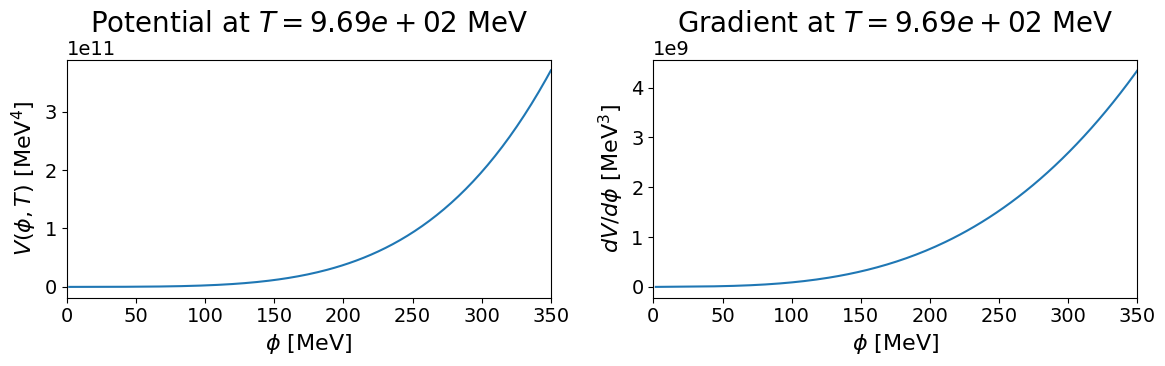

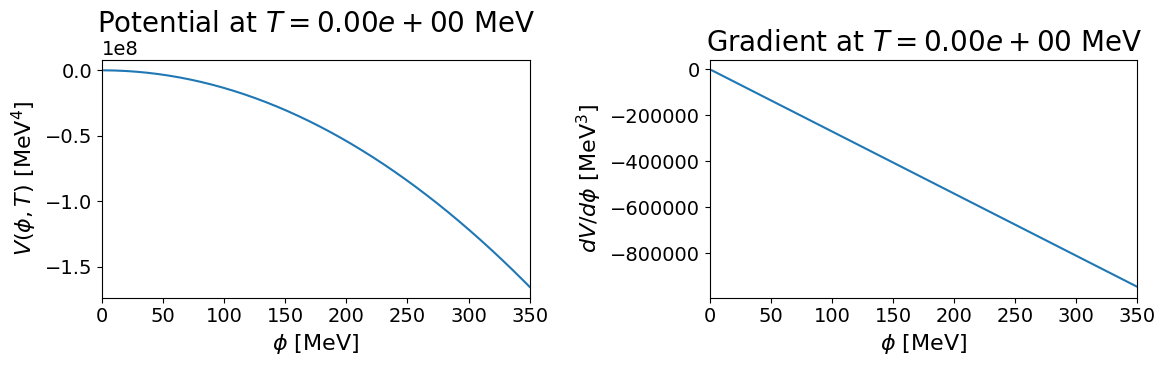

In [97]:
import matplotlib.pyplot as plt
import warnings

warnings.filterwarnings("ignore", category=SyntaxWarning)

# Set global font size parameters
plt.rcParams.update({
    'font.size': 18,
    'axes.titlesize': 20,
    'axes.labelsize': 16,
    'xtick.labelsize': 14,
    'ytick.labelsize': 14,
    'legend.fontsize': 14,
    'figure.titlesize': 20,
    'text.usetex': False    # <<< IMPORTANT for Colab
})

T = np.random.uniform(0, 3*vev)

phi = np.linspace(0, .7 * vev, 200)
phi = phi.reshape(-1,1)

for t in [T, 0]:
    v = V(phi, t)
    dv = dV(phi, t)

    fig, axes = plt.subplots(1, 2, figsize=(12, 4))

    axes[0].plot(phi, v)
    axes[0].set_title(f"Potential at $T = {t:.2e}$ {units}")
    axes[0].set_xlabel(f"$\\phi$ [{units}]")
    axes[0].set_ylabel(f"$V(\\phi, T)$ [{units}$^4$]")

    axes[1].plot(phi[1:], dv[1:])
    axes[1].set_title(f"Gradient at $T = {t:.2e}$ {units}")
    axes[1].set_xlabel(f"$\\phi$ [{units}]")
    axes[1].set_ylabel(f"$dV/d\\phi$ [{units}$^3$]")

    for ax in axes:
        ax.set_xlim(phi[0], phi[-1])

    plt.tight_layout()
    plt.show()



In [98]:
import numpy as np
import temperatures as temp

def find_extrema_fast(V, dV_unused, T, Phimax=150, step=1, *, max_expand=10, Phimax_cap=2e4):
    T = float(T)
    if T < 0:
        return [], [], []

    Phimax = float(Phimax)
    step   = float(step)

    # IMPORTANT: mimic ELENA -> start at phi=step (exclude phi=0)
    phi = np.arange(step, Phimax + step, step, dtype=float).reshape(-1, 1)
    v = np.asarray(V(phi, T), dtype=float).reshape(-1)

    argmaxV = np.argmax(v)
    expand_counter = 0
    while (argmaxV + 1) != len(v):
        if np.isnan(v[argmaxV]):
            return [], [], []
        expand_counter += 1
        if expand_counter > max_expand or Phimax >= Phimax_cap:
            break
        Phimax = min(Phimax_cap, 2.0 * Phimax)
        phi = np.arange(step, Phimax + step, step, dtype=float).reshape(-1, 1)
        v = np.asarray(V(phi, T), dtype=float).reshape(-1)
        argmaxV = np.argmax(v)

    if len(v) < 5 or not np.all(np.isfinite(v)):
        return [], [], []

    # Derivative from V-grid (uniform step)
    phi1 = phi.reshape(-1)
    dv = np.gradient(v, phi1)

    signs = np.sign(dv).reshape(-1)
    signs = np.round(signs).astype(int)

    sign_changes = np.diff(signs)  # negative: max, positive: min
    change_indices = np.nonzero(np.abs(sign_changes) == 2)[0]

    # Same "de-dup consecutive flips" logic as ELENA
    filtered = []
    previous = 0
    for idx in np.flip(change_indices):
        if idx != previous - 1:
            filtered.append(idx)
        previous = idx
    filtered = np.flip(np.array(filtered, dtype=int))

    loc, val, kind = [], [], []
    for idx in filtered:
        this_one = "max" if sign_changes[idx] < 0 else "min"

        dv_pair = dv[idx:idx+2]
        phi_pair = phi1[idx:idx+2]
        v_pair = v[idx:idx+2]

        # linear interpolate dv=0 crossing
        if this_one == "max":
            xz = np.interp(0.0, dv_pair[::-1], phi_pair[::-1])
        else:
            xz = np.interp(0.0, dv_pair, phi_pair)

        vz = np.interp(xz, phi_pair, v_pair)

        kind.append(this_one)
        loc.append(float(xz))
        val.append(float(vz))

    if len(kind) == 0:
        return [], [], []

    # sort by location
    order = np.argsort(loc)
    kind = (np.array(kind)[order]).tolist()
    loc  = (np.array(loc)[order]).tolist()
    val  = (np.array(val)[order]).tolist()

    # truncate after global minimum (same idea as ELENA)
    if len(kind) > 2:
        gmin = int(np.argmin(val))
        kind = kind[:gmin+1]
        loc  = loc[:gmin+1]
        val  = val[:gmin+1]

    return kind, loc, val

# patch
temp.find_extrema = find_extrema_fast


In [99]:
import numpy as np

from temperatures import find_T_min, find_T_max, refine_Tmin
from potential_3d import V, dV   # your 3D potential + derivative

# --- user settings ---
vev   = 500.0
units = "MeV"

# IMPORTANT:
# ELENA's default in the class is tmax = 2.5*vev (see source),
# but if you expect a feature near ~1310 MeV and vev=500, you need tmax > 1310.
tmax = 3* vev   # e.g. 1600 MeV
T_step = 1e-2      # matches ELENA default style (step_phi = vev*T_step)

# -----------------------------
# ELENA-style temperature scan
# -----------------------------
T_max, vevs_max, max_min_vals, false_min_tmax = find_T_max(
    V, dV,
    precision=1e-2,
    Phimax=2*vev,
    step_phi=vev * T_step,
    tmax=tmax
)

T_min, vevs_min, false_min_tmin = find_T_min(
    V, dV,
    tmax=T_max,
    precision=1e-2,
    Phimax=2*vev,
    step_phi=vev * T_step,
    max_min_vals=max_min_vals
)

# maxvev selection (exact ELENA logic)
if T_max is not None and T_min is not None:
    maxvev = np.max(np.concatenate((vevs_max, vevs_min)))
elif T_max is not None:
    maxvev = np.max(vevs_max)
elif T_min is not None:
    maxvev = np.max(vevs_min)
else:
    maxvev = None

# refine Tmin (exact ELENA call)
T_min = refine_Tmin(T_min, V, dV, maxvev, log_10_precision=6) if T_min is not None else None

# -----------------------------
# Print results
# -----------------------------
print(f"T_max = {T_max:.6e} {units}" if T_max is not None else "T_max = None")
print(f"T_min = {T_min:.6e} {units}" if T_min is not None else "T_min = None")

if vevs_max is not None:
    print("vevs_max (sample):", vevs_max[:10])
if vevs_min is not None:
    print("vevs_min (sample):", vevs_min[:10])


T_max = 1.341000e+02 MeV
T_min = 1.075096e+02 MeV
vevs_max (sample): [26.28979092 26.18952257 26.17462963]
vevs_min (sample): [31.76443343]


In [100]:
T_max, vevs_max, max_min_vals, false_min_tmax

(np.float64(134.09999999999997),
 array([26.28979092, 26.18952257, 26.17462963]),
 [13.289570920374622, 26.17462963427888],
 [0, 0])

In [101]:
T_min, vevs_min, false_min_tmin

(np.float64(107.50958131448104), array([31.76443343]), [0, 0])

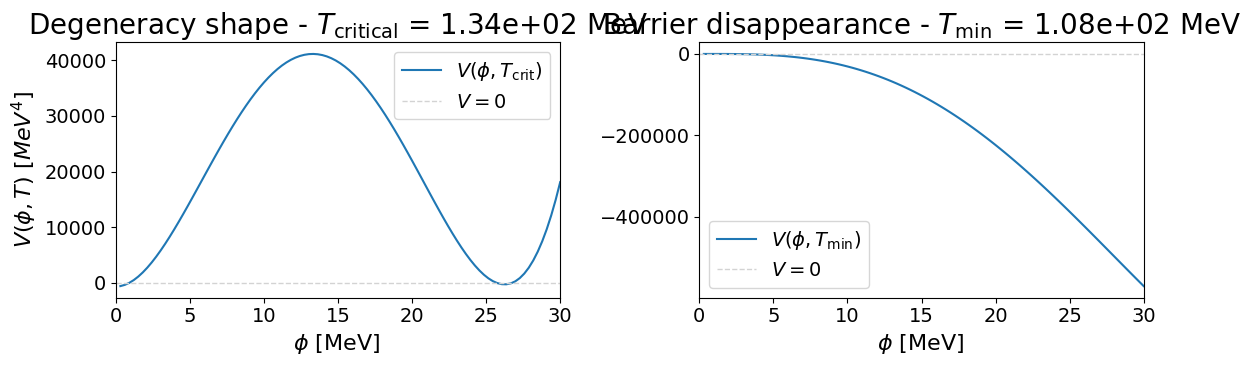

In [102]:
import matplotlib.pyplot as plt
plt.rcParams['text.usetex'] = False
phi= np.linspace(0, 0.06*vev, 100)
if T_max is not None: v_max = V(phi, T_max)
if T_min is not None: v_min = V(phi, T_min)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

if T_max is not None:
    v_max = V(phi, T_max)
    axes[0].plot(phi, v_max, label = '$V(\phi, T_{\mathrm{{crit}}})$')
    axes[0].set_title(f'Degeneracy shape - $T_{{\mathrm{{critical}}}}$ = {T_max:.2e} {units}')
    axes[0].set_xlim(phi[0], phi[-1])
    axes[0].set_ylabel(f"$V(\phi, T)$ $[{units}^{4}]$")

if T_min is not None:
    v_min = V(phi, T_min)
    axes[1].plot(phi, v_min, label= '$V(\phi, T_{\mathrm{{min}}})$')
    axes[1].set_title(f'Barrier disappearance - $T_{{\mathrm{{min}}}}$ = {T_min:.2e} {units}')
    axes[1].set_xlim(phi[0], phi[-1])

for ax in axes:
    ax.set_xlabel(f"$\phi$ [{units}] ")
    ax.axhline(false_min_tmax[1], color='lightgrey', linestyle='--', linewidth=1, label = "$V = 0$")
    ax.legend()

plt.tight_layout()
plt.show()

In [103]:
maxvev

np.float64(31.764433426256428)

In [104]:
import numpy as np
from espinosa import Vt_vec

def V_1d(phi, T):
    out = V(phi, T)
    a = np.asarray(out, dtype=float)
    return float(a) if a.ndim == 0 else a.reshape(-1)

def dV_1d(phi, T):
    out = dV(phi, T)
    a = np.asarray(out, dtype=float)
    return float(a) if a.ndim == 0 else a.reshape(-1)

true_vev = {}
false_vev = {}
S3overT = {}
V_min_value = {}
phi0_min = {}
V_exit = {}

def action_over_T(T, c_step_phi=1e-3, precision=1e-3):
    instance = Vt_vec(
        T, V_1d, dV_1d,
        step_phi=c_step_phi,
        precision=precision,
        vev0=maxvev,
        ratio_vev_step0=50
    )
    if instance.barrier:
        true_vev[T] = instance.true_min
        false_vev[T] = instance.phi_original_false_vev
        S3overT[T] = instance.action_over_T
        V_min_value[T] = instance.min_V
        phi0_min[T] = instance.phi0_min
        V_exit[T] = instance.V_exit
        return instance.action_over_T
    return None


In [105]:
import time

n_points = 100
temperatures = np.linspace(T_min, T_max, n_points)
action_vec = np.vectorize(action_over_T)

start_time = time.time()
action_vec(temperatures)
end_time = time.time()
print(f"Elapsed time: {end_time - start_time:.2f} seconds")

temperatures = temperatures = np.array(sorted(S3overT.keys()))


Elapsed time: 5.19 seconds


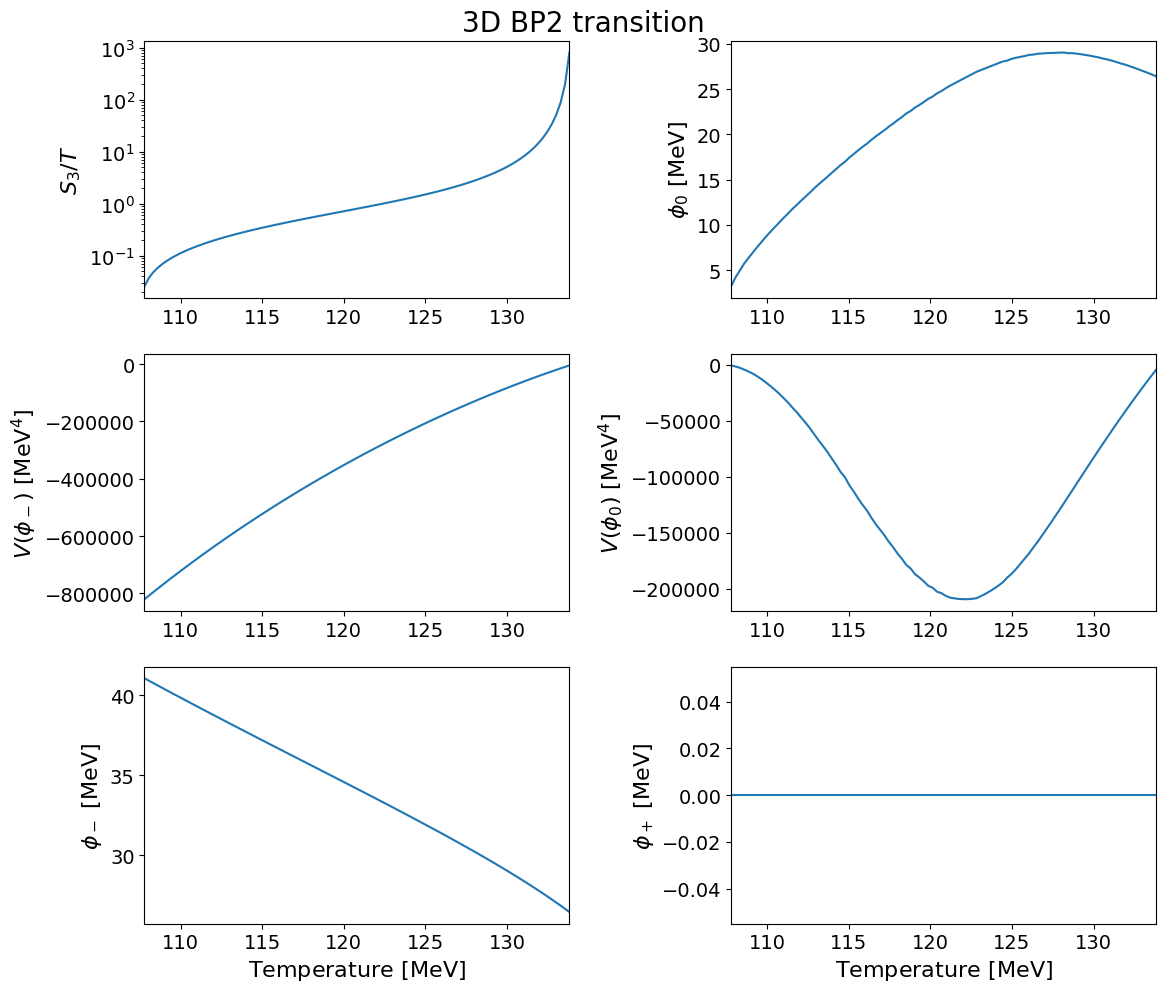

Minimum of the action at T = 1.08e+02 MeV


In [106]:
import matplotlib.pyplot as plt
from pathlib import Path

# Define the directory to save figures
figure_dir = "figures/"
Path(figure_dir).mkdir(parents=True, exist_ok=True)

fig, axes = plt.subplots(3, 2, figsize=(12, 10))

axes[0, 0].plot(temperatures, [S3overT[T] for T in temperatures])
#axes[0, 0].set_title('$S_3/T$')
#axes[0, 0].set_xlabel(f"T [{units}]")
axes[0, 0].set_ylabel('$S_3/T$')
axes[0, 0].set_yscale('log')

axes[0, 1].plot(temperatures, [phi0_min[T] for T in temperatures])
#axes[0, 1].set_title('$\phi_{0,\mathrm{min}}$')
#axes[0, 1].set_xlabel(f"T [{units}]")
axes[0, 1].set_ylabel(f"$\phi_0\ \mathrm{{[{units}]}}$")

axes[1, 0].plot(temperatures, [V_min_value[T] for T in temperatures])
#axes[1, 0].set_title('V(true_vev)')
#axes[1, 0].set_xlabel(f"T [{units}]")
axes[1, 0].set_ylabel(f"$V(\phi_-)\ \mathrm{{[{units}^4]}}$")

axes[1, 1].plot(temperatures, [V_exit[T] for T in temperatures])
#axes[1, 1].set_title('$V(\phi_{0,\mathrm{min}})$')
#axes[1, 1].set_xlabel(f"T [{units}]")
axes[1, 1].set_ylabel(f"$V(\phi_0)\ \mathrm{{[{units}^4]}}$")

axes[2, 0].plot(temperatures, [true_vev[T] for T in temperatures])
#axes[2, 0].set_title('True vev')
axes[2, 0].set_xlabel(f"$\mathrm{{Temperature\ [{units}]}}$")
axes[2, 0].set_ylabel(f"$\phi_-\ \mathrm{{[{units}]}}$")

axes[2, 1].plot(temperatures, [false_vev[T] for T in temperatures])
#axes[2, 1].set_title('False vev')
axes[2, 1].set_xlabel(f"$\mathrm{{Temperature\ [{units}]}}$")
axes[2, 1].set_ylabel(f"$\phi_+\ \mathrm{{[{units}]}}$")

for ax in axes.flatten():
    ax.set_xlim(temperatures[0], temperatures[-1])

plt.tight_layout()
fig.suptitle(f'{description} transition', y=1.00)
plt.savefig(figure_dir + f"action_{description}.pdf", dpi=300, bbox_inches='tight')
plt.show()

print(f"Minimum of the action at T = {temperatures[np.argmin([S3overT[T] for T in temperatures])]:.2e} {units}")

In [107]:
import importlib, inspect
import numpy as np
import temperatures as temp

# 1) reset the module (undo previous monkey patches)
temp = importlib.reload(temp)

# 2) patch s_SM so it accepts `units=` (only if the real one doesn't)
_sig = inspect.signature(temp.s_SM)
if "units" not in _sig.parameters:
    _real_s_SM = temp.s_SM
    def s_SM(T, units=None):
        return _real_s_SM(T)
    temp.s_SM = s_SM

def _asfloat(x):
    return float(np.asarray(x, dtype=float).squeeze())

# 3) safe compute_logP_f (forces scalars/1D everywhere)
def compute_logP_f_safe(m, V_min_value, S3overT, v_w, units='GeV', cum_method='cumulative_simpson'):
    # choose cumulative integrator
    if cum_method == 'cumulative_simpson' and hasattr(temp, "cumulative_simpson"):
        cum_f = temp.cumulative_simpson
    else:
        from scipy.integrate import cumulative_trapezoid
        cum_f = cumulative_trapezoid

    # Correctly reference the potential function from CustomModel
    V = m.DVtot

    Temps = np.array(sorted(set(V_min_value.keys()) & set(S3overT.keys())), dtype=float)
    if Temps.size < 2:
        return np.array([]), Temps, np.array([]), np.array([]), np.array([])

    steps = len(Temps)
    T_step = max((Temps[-1] - Temps[0]) * 1e-3, 1e-6)

    def finite_dVdT(phi, T, step=T_step):
        Tm = max(T - step, 0.0)
        Tp = T + step
        if Tm == T:
            val = (V(np.array([phi]), Tp) - V(np.array([phi]), T)) / step
        else:
            val = (V(np.array([phi]), Tp) - V(np.array([phi]), Tm)) / (Tp - Tm)
        return _asfloat(val) - temp.s_SM(T, units=units)

    def finite_d2VdT2(phi, T):
        step2 = 0.5 * T_step
        Tm = max(T - step2, 0.0)
        Tp = T + step2
        if Tm == T:
            Tpp = T + 2 * step2
            f0 = finite_dVdT(phi, T,  step2)
            f1 = finite_dVdT(phi, Tp, step2)
            f2 = finite_dVdT(phi, Tpp, step2)
            return (f2 - 2*f1 + f0) / (step2**2)
        f_plus  = finite_dVdT(phi, Tp, step2)
        f_minus = finite_dVdT(phi, Tm, step2)
        return (f_plus - f_minus) / (Tp - Tm)

    e_vacuum = np.array([-_asfloat(V_min_value[t]) for t in Temps], dtype=float)
    e_radiation = np.pi**2 * temp.g_rho(Temps / temp.convert_units[units]) * Temps**4 / 30.0
    H = np.sqrt((e_vacuum + e_radiation) / 3.0) / (temp.M_pl * temp.convert_units[units])

    S3_T = np.array([_asfloat(S3overT[t]) for t in Temps], dtype=float)
    Gamma = Temps**4 * (S3_T / (2*np.pi))**(3/2) * np.exp(-S3_T)

    # Use a small non-zero phi value to avoid division by zero in V(phi,T)
    phi_for_ratio_V = _phi_safe(0.0)
    ratio_V = np.array([finite_d2VdT2(phi_for_ratio_V, T) / finite_dVdT(phi_for_ratio_V, T) for T in Temps], dtype=float)

    logP_f = np.zeros_like(Temps, dtype=float)
    f_ext = ratio_V * Gamma / H

    # integrate
    for i in range(steps - 1):
        cum_ratio_V = cum_f(ratio_V[i:], x=Temps[i:], initial=0.0)

        f1 = ratio_V[i:] / H[i:] * np.exp(cum_ratio_V / 3.0)
        cum_f1 = cum_f(f1, x=Temps[i:], initial=0.0)

        f2 = f_ext[i:] * np.exp(-cum_ratio_V) * (cum_f1**3)
        cum_f2 = cum_f(f2, x=Temps[i:], initial=0.0)

        logP_f[i] = - (4.0/243.0) * np.pi * (v_w**3) * cum_f2[-1]

    return logP_f, Temps, ratio_V, Gamma, H

temp.compute_logP_f = compute_logP_f_safe

print("Patched: temperatures.s_SM and temperatures.compute_logP_f (safe).")

Patched: temperatures.s_SM and temperatures.compute_logP_f (safe).


In [108]:
import numpy as np
from scipy.integrate import cumulative_trapezoid

import temperatures as temp
from dof_interpolation import g_rho
from utils import convert_units

def _crossing_linear(x, y, ystar):
    """
    Return x where y crosses ystar (linear interp). Assumes x increasing.
    Picks the first crossing from high-T side (largest x) going down in T if needed.
    """
    x = np.asarray(x, float)
    y = np.asarray(y, float)

    m = np.isfinite(x) & np.isfinite(y)
    x, y = x[m], y[m]
    if x.size < 2:
        return np.nan

    # find any sign change in (y-ystar)
    s = y - ystar
    idx = np.where(s[:-1] * s[1:] <= 0)[0]
    if idx.size == 0:
        return np.nan

    i = idx[0]
    x0, x1 = x[i], x[i+1]
    y0, y1 = y[i], y[i+1]
    if y1 == y0:
        return 0.5*(x0 + x1)
    return x0 + (ystar - y0) * (x1 - x0) / (y1 - y0)

def compute_logP_f_fixed(V_min_value, S3overT, *, v_w=1.0, units="MeV",
                         use_g_running=True, clip_exp=700.0):
    # Use only temps that exist in BOTH dicts
    Temps = np.array(sorted(set(V_min_value.keys()) & set(S3overT.keys())), dtype=float)
    if Temps.size < 3:
        raise RuntimeError("Need >=3 temperatures with both V_min_value and S3overT.")

    # Vacuum + radiation energy density -> H(T)
    e_vac = np.array([-V_min_value[T] for T in Temps], dtype=float)
    g = np.asarray(g_rho(Temps / convert_units[units]), dtype=float)
    e_rad = (np.pi**2 / 30.0) * g * Temps**4
    H = np.sqrt(np.maximum(e_vac + e_rad, 0.0) / 3.0) / (temp.M_pl * convert_units[units])

    # Nucleation rate prefactor
    S3_T = np.array([S3overT[T] for T in Temps], dtype=float)
    S3_clip = np.clip(S3_T, 0.0, clip_exp)  # stabilise exp(-S3/T)
    Gamma = Temps**4 * (np.maximum(S3_T, 0.0) / (2*np.pi))**1.5 * np.exp(-S3_clip)

    # ---- KEY FIX: ratio_V for radiation era (because your V dropped the constant T^4 term)
    if use_g_running:
        ln_g = np.log(np.maximum(g, 1e-300))
        dln_g_dT = np.gradient(ln_g, Temps)
        ratio_V = 3.0/Temps + dln_g_dT
    else:
        ratio_V = 3.0/Temps

    # Same structure as ELENA compute_logP_f
    logP_f = np.zeros_like(Temps)
    f_ext = ratio_V * Gamma / np.maximum(H, 1e-300)

    for i in range(len(Temps) - 1):
        Ts = Temps[i:]
        r  = ratio_V[i:]
        Hs = H[i:]
        fE = f_ext[i:]

        cum_r = cumulative_trapezoid(r, x=Ts, initial=0.0)

        f1 = r/np.maximum(Hs, 1e-300) * np.exp(cum_r/3.0)
        cum_f1 = cumulative_trapezoid(f1, x=Ts, initial=0.0)

        f2 = fE * np.exp(-cum_r) * cum_f1**3
        cum_f2 = cumulative_trapezoid(f2, x=Ts, initial=0.0)

        logP_f[i] = -(4.0/243.0) * np.pi * (v_w**3) * cum_f2[-1]

    return logP_f, Temps, ratio_V, Gamma, H

# ----------------------------
# RUN + milestones
# ----------------------------
logP_f, Temps, ratio_V, Gamma, H = compute_logP_f_fixed(
    V_min_value, S3overT, v_w=1.0, units=units, use_g_running=True
)

P_f = np.exp(np.clip(logP_f, -700.0, 0.0))  # physical volume fraction (0..1)
nH  = temp.N_bubblesH(Temps, Gamma, logP_f, H, ratio_V)

print(f"Temps range: {Temps[0]} → {Temps[-1]}   N={len(Temps)}")
print(f"ratio_V range: {np.nanmin(ratio_V)} → {np.nanmax(ratio_V)}")
print(f"logP_f range: {np.nanmin(logP_f)} → {np.nanmax(logP_f)}")
print(f"P_f range: {np.nanmin(P_f)} → {np.nanmax(P_f)}")
print(f"nH range: {np.nanmin(nH)} → {np.nanmax(nH)}")

T_nuc = _crossing_linear(Temps, nH, 1.0)
T_perc = _crossing_linear(Temps, P_f, 0.71)
T_completion = _crossing_linear(Temps, P_f, 0.01)

print(f"\nT_nuc = {T_nuc} {units}")
print(f"T_perc = {T_perc} {units}")
print(f"T_completion = {T_completion} {units}")

if np.isnan(T_nuc):
    print("Note: No nucleation found in this window (max(nH) < 1). Try extending the T scan.")
if np.isnan(T_perc):
    print("Note: P_f never reached 0.71 in this window.")
if np.isnan(T_completion):
    print("Note: P_f never reached 0.01 in this window.")


Temps range: 107.77817140221356 → 133.83140991226745   N=98
ratio_V range: 0.03148445738909317 → 0.03555947485246167
logP_f range: -2.554193837703978e+72 → 0.0
P_f range: 9.85967654375977e-305 → 1.0
nH range: -0.0 → 6.736795457054532e+37

T_nuc = 133.56281982453493 MeV
T_perc = 133.21633861136002 MeV
T_completion = 133.02832554994725 MeV


In [109]:
T_min

np.float64(107.50958131448104)

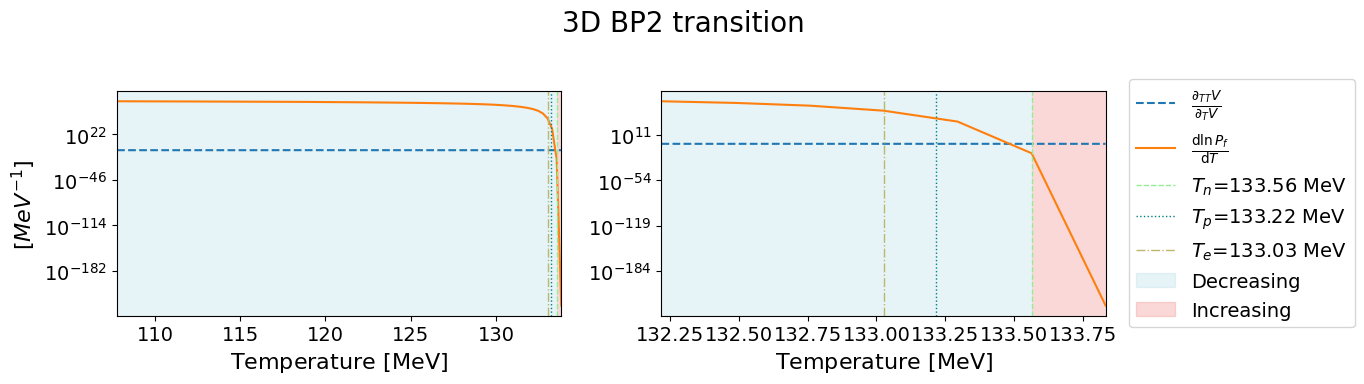

In [110]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

# ---- required inputs assumed to exist ----
# Temps, ratio_V, logP_f, T_nuc, T_perc, T_completion, units

# optional labels/paths
description = globals().get("description", "3D DR")
figure_dir  = globals().get("figure_dir", "")

# ---- derivatives for plotting ----
d_dT_logP_f = np.gradient(logP_f, Temps)

# ---- plotting-safe versions (log-scale cannot show <=0) ----
floor = 1e-300
ratio_plot = np.clip(np.abs(ratio_V), floor, None)
dlogP_plot = np.clip(np.abs(d_dT_logP_f), floor, None)

# ---- zoom mask around milestones (for right panel) ----
t_mil_min = np.nanmin([T_completion, T_perc, T_nuc])
t_mil_max = np.nanmax([T_completion, T_perc, T_nuc])

i0 = max(int(np.argmin(np.abs(Temps - t_mil_min))) - 3, 0)
i1 = min(int(np.argmin(np.abs(Temps - t_mil_max))) + 3, len(Temps)-1)
mask = np.zeros_like(Temps, dtype=bool)
mask[i0:i1+1] = True

# ---- figure ----
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# left: full range
axes[0].plot(Temps, ratio_plot, label=r"$\frac{\partial_{TT}V}{\partial_T V}$", linestyle="--")
axes[0].plot(Temps, dlogP_plot, label=r"$$\frac{\mathrm{d}\ln P_f}{\mathrm{d}T}$")
axes[0].set_xlim(Temps[0], Temps[-1])
axes[0].set_ylabel(rf"$[{units}^{{-1}}]$")

# right: zoomed range
axes[1].plot(Temps[mask], ratio_plot[mask], label=r"$\frac{\partial_{TT}V}{\partial_T V}$", linestyle="--")
axes[1].plot(Temps[mask], dlogP_plot[mask], label=r"$\frac{\mathrm{d}\ln P_f}{\mathrm{d}T}$")
axes[1].set_xlim(Temps[mask][0], Temps[mask][-1])

# legend patches for shading
decreasing_patch = mpatches.Patch(color="lightblue",  alpha=0.3, label="Decreasing")
increasing_patch = mpatches.Patch(color="lightcoral", alpha=0.3, label="Increasing")

for ax in axes:
    ax.set_yscale("log")
    ax.set_xlabel(rf"$\mathrm{{Temperature\ [{units}]}}$")

    ax.axvline(T_nuc,        color="lightgreen", linestyle="--", linewidth=1, label=rf"$T_n$={T_nuc:.2f} {units}")
    ax.axvline(T_perc,       color="teal",       linestyle=":",  linewidth=1, label=rf"$T_p$={T_perc:.2f} {units}")
    ax.axvline(T_completion, color="darkkhaki",  linestyle="-.", linewidth=1, label=rf"$T_e$={T_completion:.2f} {units}")

    # shading (use the SAME abs-comparison you’re plotting)
    for i in range(len(Temps) - 1):
        if dlogP_plot[i] >= ratio_plot[i]:
            ax.axvspan(Temps[i], Temps[i+1], facecolor="lightblue", alpha=0.3)
        else:
            ax.axvspan(Temps[i], Temps[i+1], facecolor="lightcoral", alpha=0.3)

# put a clean legend outside on the right
handles, labels = axes[1].get_legend_handles_labels()
handles += [decreasing_patch, increasing_patch]
labels  += [decreasing_patch.get_label(), increasing_patch.get_label()]
axes[1].legend(handles=handles, labels=labels, loc="center left", bbox_to_anchor=(1.03, 0.5))

fig.suptitle(f"{description} transition", y=0.98)
plt.tight_layout()
plt.savefig(figure_dir + f"volume_{description}.pdf", dpi=300, bbox_inches="tight")
plt.show()


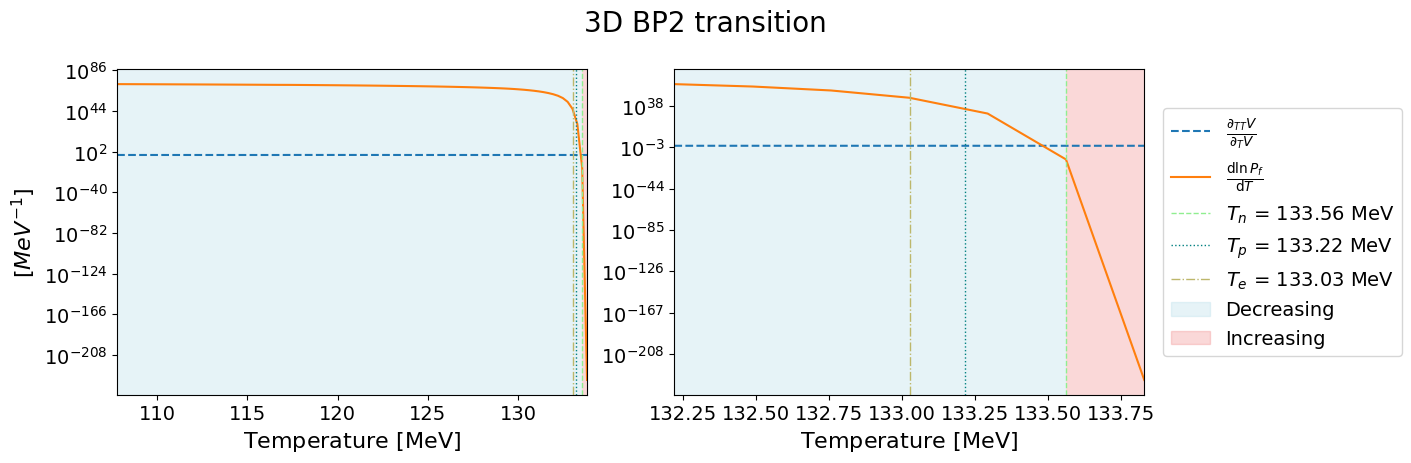

In [111]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import os

# assumes you already have:
# Temps, ratio_V, logP_f, T_nuc, T_perc, T_completion, units, description, figure_dir
# and (optionally) mask

# ---------- derive d/dT log(P_f) ----------
d_dT_logP_f = np.gradient(logP_f, Temps)

# ---------- log-scale safe arrays (plotting only) ----------
ratio_plot = np.clip(np.asarray(ratio_V, float), 1e-300, None)
dlog_plot  = np.clip(np.asarray(d_dT_logP_f, float), 1e-300, None)

# ---------- define zoom mask if not present / too small ----------
if "mask" not in globals() or np.sum(mask) < 3:
    t_lo = np.nanmin([T_completion, T_perc, T_nuc])
    t_hi = np.nanmax([T_completion, T_perc, T_nuc])
    mask = (Temps >= t_lo) & (Temps <= t_hi)
    if np.sum(mask) < 3:
        mask = np.ones_like(Temps, dtype=bool)

# ---------- intersections between (d/dT logP_f) and (ratio_V) ----------
diff = np.asarray(d_dT_logP_f, float) - np.asarray(ratio_V, float)
finite = np.isfinite(Temps) & np.isfinite(diff)
T_f = Temps[finite]
d_f = diff[finite]

intersections = []
for i in range(len(T_f) - 1):
    y1, y2 = d_f[i], d_f[i + 1]
    if y1 == 0.0:
        intersections.append(float(T_f[i]))
    if y1 * y2 < 0.0:
        x1, x2 = T_f[i], T_f[i + 1]
        # linear root of y(x)=0
        intersections.append(float(x1 - y1 * (x2 - x1) / (y2 - y1)))

# points for precise shading
all_points = np.unique(np.clip(np.concatenate([Temps, intersections]), Temps.min(), Temps.max()))
all_points.sort()

# ---------- plot ----------
os.makedirs(figure_dir, exist_ok=True)
fig, axes = plt.subplots(1, 2, figsize=(14, 4), constrained_layout=True)

# full panel
axes[0].plot(Temps, ratio_plot, label=r"$V_{TT}/V_T$", linestyle="--")
axes[0].plot(Temps, dlog_plot,  label=r"$\mathrm{d}\ln P_f/\mathrm{d}T$")
axes[0].set_xlim(Temps[0], Temps[-1])
axes[0].set_ylabel(rf"$[{units}^{{-1}}]$")

# zoom panel
axes[1].plot(Temps[mask], ratio_plot[mask], label=r"$\frac{\partial_{TT}V}{\partial_T V}$", linestyle="--")
axes[1].plot(Temps[mask], dlog_plot[mask],  label=r"$\frac{\mathrm{d}\ln P_f}{\mathrm{d}T}$")
axes[1].set_xlim(Temps[mask][0], Temps[mask][-1])

# legend patches
decreasing_patch = mpatches.Patch(color="lightblue",  alpha=0.3, label="Decreasing")
increasing_patch = mpatches.Patch(color="lightcoral", alpha=0.3, label="Increasing")

for ax in axes:
    ax.set_yscale("log")
    ax.set_xlabel(rf"$\mathrm{{Temperature\ [{units}]}}$")

    # milestone lines (keep labels only once per axis)
    ax.axvline(T_nuc,        color="lightgreen", linestyle="--", linewidth=1, label=rf"$T_n$ = {T_nuc:.2f} {units}")
    ax.axvline(T_perc,       color="teal",       linestyle=":",  linewidth=1, label=rf"$T_p$ = {T_perc:.2f} {units}")
    ax.axvline(T_completion, color="darkkhaki",  linestyle="-.", linewidth=1, label=rf"$T_e$ = {T_completion:.2f} {units}")

    # background shading with intersection-refined bins
    for i in range(len(all_points) - 1):
        a, b = all_points[i], all_points[i + 1]
        mid = 0.5 * (a + b)
        d_mid = np.interp(mid, Temps, d_dT_logP_f)
        r_mid = np.interp(mid, Temps, ratio_V)

        if np.isfinite(d_mid) and np.isfinite(r_mid):
            if d_mid >= r_mid:
                ax.axvspan(a, b, facecolor="lightblue",  alpha=0.3)
            else:
                ax.axvspan(a, b, facecolor="lightcoral", alpha=0.3)

# put legend outside on the right panel
handles, labels = axes[1].get_legend_handles_labels()
handles += [decreasing_patch, increasing_patch]
labels  += ["Decreasing", "Increasing"]
axes[1].legend(handles, labels, loc="center left", bbox_to_anchor=(1.02, 0.5))

fig.suptitle(f"{description} transition", y=1.12)
plt.savefig(os.path.join(figure_dir, f"volume_{description}.pdf"), dpi=300, bbox_inches="tight")
plt.show()


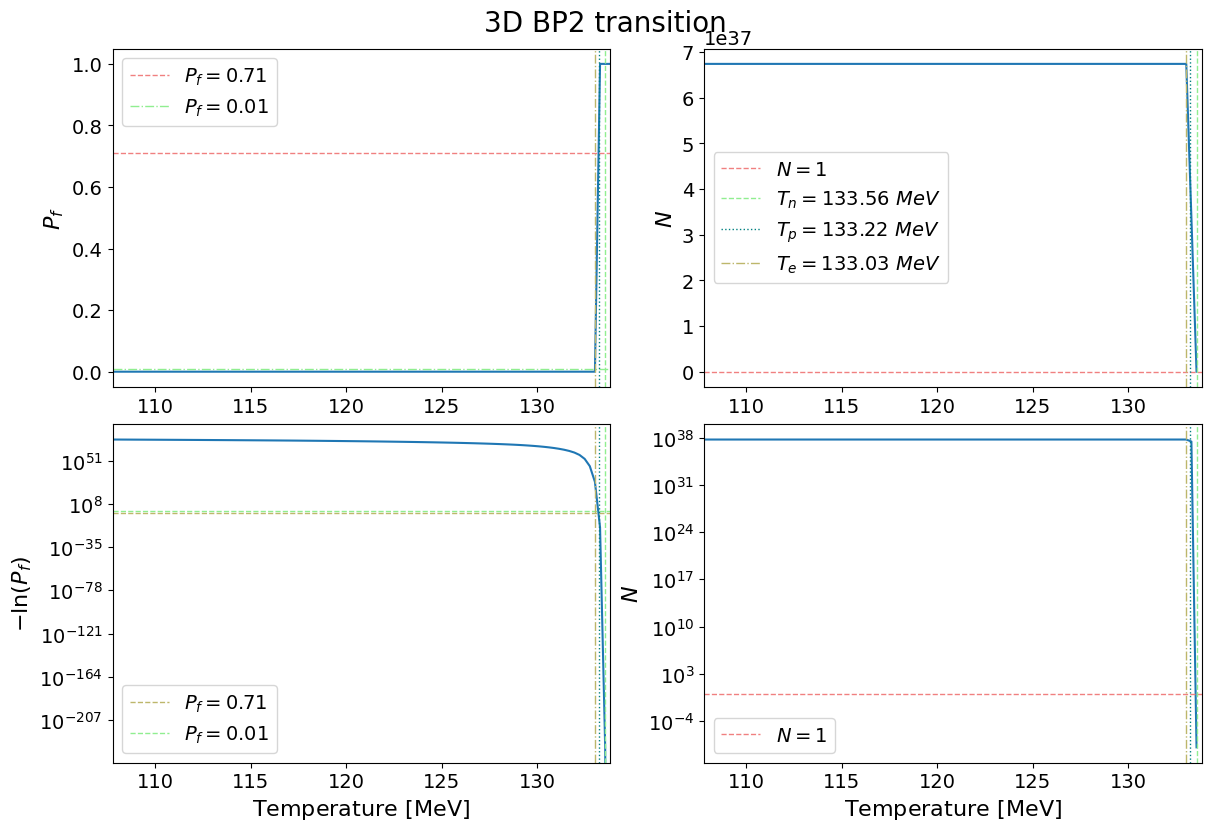

Average number of bubbles at lowest valid T, N = 6.737e+37


In [112]:
import numpy as np
import matplotlib.pyplot as plt
import os

# assumes you already have:
# Temps, logP_f, nH, T_nuc, T_perc, T_completion, units, description, figure_dir

os.makedirs(figure_dir, exist_ok=True)

# plotting-safe Pf (avoid underflow to 0 for the first panel if you want)
Pf = np.exp(np.clip(logP_f, -700.0, 0.0))

mask_nH = np.isfinite(nH) & (nH > 0)

fig, axes = plt.subplots(2, 2, figsize=(12, 8), constrained_layout=True)

# --- Pf linear ---
axes[0,0].plot(Temps, Pf)
axes[0,0].set_ylabel(r"$P_f$")
axes[0,0].axhline(0.71, color="lightcoral", linestyle="--", linewidth=1, label=r"$P_f=0.71$")
axes[0,0].axhline(0.01, color="lightgreen", linestyle="-.", linewidth=1, label=r"$P_f=0.01$")
axes[0,0].legend()

# --- N linear ---
axes[0,1].plot(Temps[mask_nH], nH[mask_nH])
axes[0,1].axhline(1, color="lightcoral", linestyle="--", linewidth=1, label=r"$N=1$")
axes[0,1].set_ylabel(r"$N$")
axes[0,1].legend()

# --- -log Pf (log y) ---
axes[1,0].plot(Temps, -logP_f)
axes[1,0].axhline(-np.log(0.71), color="darkkhaki", linestyle="--", linewidth=1, label=r"$P_f=0.71$")
axes[1,0].axhline(-np.log(0.01), color="lightgreen", linestyle="--", linewidth=1, label=r"$P_f=0.01$")
axes[1,0].set_xlabel(rf"$\mathrm{{Temperature\ [{units}]}}$")
axes[1,0].set_ylabel(r"$-\ln(P_f)$")
axes[1,0].set_yscale("log")
axes[1,0].legend()

# --- N (log y) ---
axes[1,1].plot(Temps[mask_nH], nH[mask_nH])
axes[1,1].axhline(1, color="lightcoral", linestyle="--", linewidth=1, label=r"$N=1$")
axes[1,1].set_xlabel(rf"$\mathrm{{Temperature\ [{units}]}}$")
axes[1,1].set_ylabel(r"$N$")
axes[1,1].set_yscale("log")
axes[1,1].legend()

# --- milestones: add lines without duplicating legend entries ---
for ax in axes.flatten():
    ax.axvline(T_nuc,        color="lightgreen", linestyle="--", linewidth=1)
    ax.axvline(T_perc,       color="teal",       linestyle=":",  linewidth=1)
    ax.axvline(T_completion, color="darkkhaki",  linestyle="-.", linewidth=1)
    ax.set_xlim(Temps[0], Temps[-1])

# add a single milestone legend on the top-right panel (cleaner)
milestone_handles = [
    plt.Line2D([0],[0], color="lightgreen", linestyle="--", linewidth=1, label=rf"$T_n={T_nuc:.2f}\ {units}$"),
    plt.Line2D([0],[0], color="teal",       linestyle=":",  linewidth=1, label=rf"$T_p={T_perc:.2f}\ {units}$"),
    plt.Line2D([0],[0], color="darkkhaki",  linestyle="-.", linewidth=1, label=rf"$T_e={T_completion:.2f}\ {units}$"),
]
axes[0,1].legend(handles=axes[0,1].get_legend_handles_labels()[0] + milestone_handles,
                 labels=axes[0,1].get_legend_handles_labels()[1] + [h.get_label() for h in milestone_handles],
                 loc="best")

fig.suptitle(f"{description} transition", y=1.02)
plt.savefig(os.path.join(figure_dir, f"evolution_{description}.pdf"), dpi=300, bbox_inches="tight")
plt.show()

if np.any(mask_nH):
    print(f"Average number of bubbles at lowest valid T, N = {nH[mask_nH][0]:.3e}")
else:
    print("No valid nH>0 points to report.")


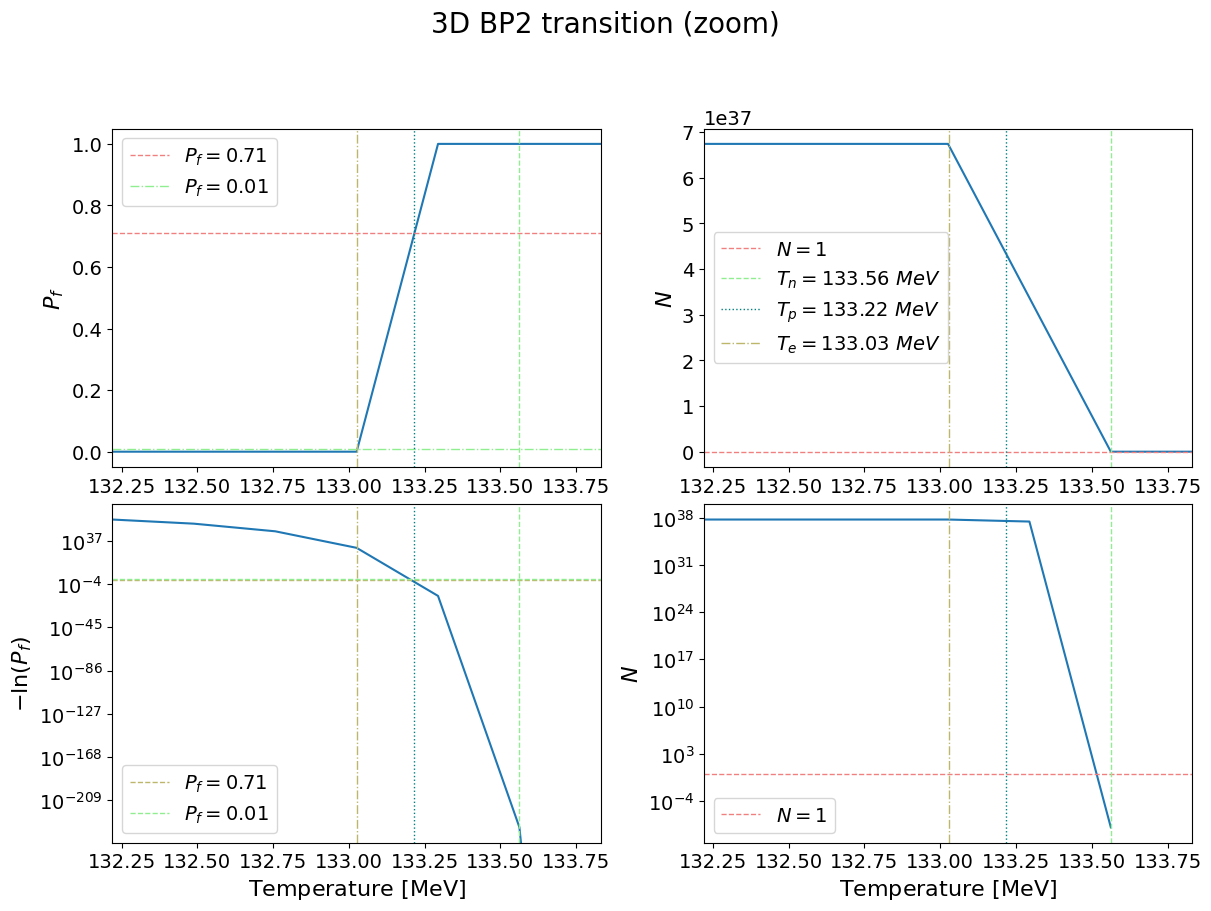

In [113]:
import numpy as np
import matplotlib.pyplot as plt
import os

# assumes you already have:
# Temps, logP_f, nH, mask, T_nuc, T_perc, T_completion, units, description, figure_dir

os.makedirs(figure_dir, exist_ok=True)

# zoom arrays
Tz = Temps[mask]
logPz = logP_f[mask]
nHz = nH[mask]

# plotting-safe Pf
Pfz = np.exp(np.clip(logPz, -700.0, 0.0))

# for log-plot of N: keep only positive finite values
mask_nH_pos = np.isfinite(nHz) & (nHz > 0)

fig, axes = plt.subplots(2, 2, figsize=(12, 8), constrained_layout=True)

# Pf (linear)
axes[0,0].plot(Tz, Pfz)
axes[0,0].set_ylabel(r"$P_f$")
axes[0,0].axhline(0.71, color="lightcoral", linestyle="--", linewidth=1, label=r"$P_f=0.71$")
axes[0,0].axhline(0.01, color="lightgreen", linestyle="-.", linewidth=1, label=r"$P_f=0.01$")
axes[0,0].legend()

# N (linear)
axes[0,1].plot(Tz, nHz)
axes[0,1].axhline(1, color="lightcoral", linestyle="--", linewidth=1, label=r"$N=1$")
axes[0,1].set_ylabel(r"$N$")
axes[0,1].legend()

# -log Pf (log y)
axes[1,0].plot(Tz, -logPz)
axes[1,0].axhline(-np.log(0.71), color="darkkhaki", linestyle="--", linewidth=1, label=r"$P_f=0.71$")
axes[1,0].axhline(-np.log(0.01), color="lightgreen", linestyle="--", linewidth=1, label=r"$P_f=0.01$")
axes[1,0].set_xlabel(rf"$\mathrm{{Temperature\ [{units}]}}$")
axes[1,0].set_ylabel(r"$-\ln(P_f)$")
axes[1,0].set_yscale("log")
axes[1,0].legend()

# N (log y) – use positive points only
axes[1,1].plot(Tz[mask_nH_pos], nHz[mask_nH_pos])
axes[1,1].axhline(1, color="lightcoral", linestyle="--", linewidth=1, label=r"$N=1$")
axes[1,1].set_xlabel(rf"$\mathrm{{Temperature\ [{units}]}}$")
axes[1,1].set_ylabel(r"$N$")
axes[1,1].set_yscale("log")
axes[1,1].legend()

# milestone vertical lines (avoid duplicating legend spam)
for ax in axes.flatten():
    ax.axvline(T_nuc,        color="lightgreen", linestyle="--", linewidth=1)
    ax.axvline(T_perc,       color="teal",       linestyle=":",  linewidth=1)
    ax.axvline(T_completion, color="darkkhaki",  linestyle="-.", linewidth=1)
    ax.set_xlim(Tz[0], Tz[-1])

# add one milestone legend (clean) in top-right panel
milestone_handles = [
    plt.Line2D([0],[0], color="lightgreen", linestyle="--", linewidth=1, label=rf"$T_n={T_nuc:.2f}\ {units}$"),
    plt.Line2D([0],[0], color="teal",       linestyle=":",  linewidth=1, label=rf"$T_p={T_perc:.2f}\ {units}$"),
    plt.Line2D([0],[0], color="darkkhaki",  linestyle="-.", linewidth=1, label=rf"$T_e={T_completion:.2f}\ {units}$"),
]
h0, l0 = axes[0,1].get_legend_handles_labels()
axes[0,1].legend(h0 + milestone_handles, l0 + [h.get_label() for h in milestone_handles], loc="best")

fig.suptitle(f"{description} transition (zoom)", y=1.12)
plt.savefig(os.path.join(figure_dir, f"evolution_{description}_zoom.pdf"), dpi=300, bbox_inches="tight")
plt.show()


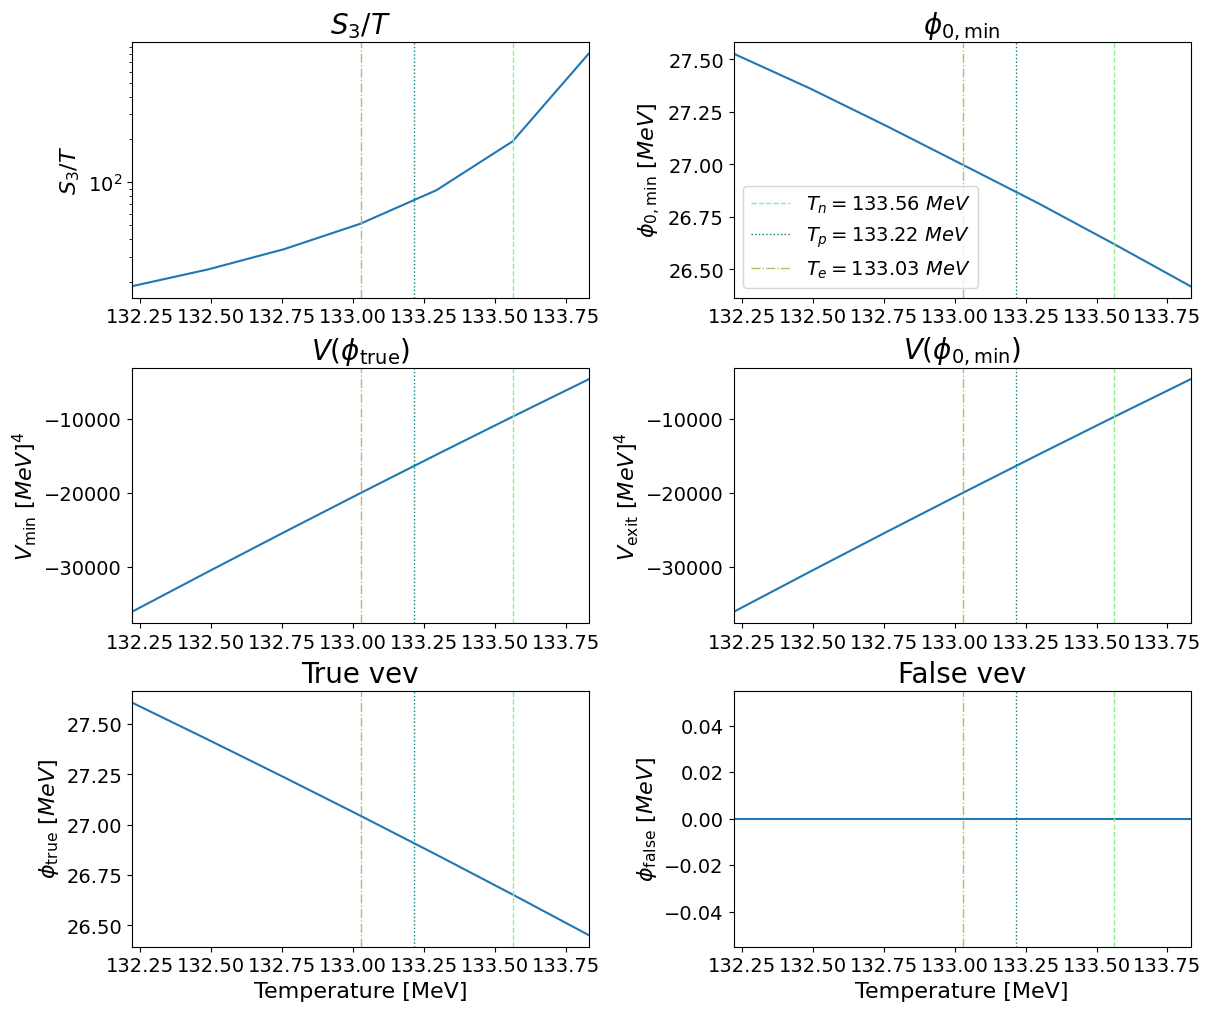

In [114]:
import numpy as np
import matplotlib.pyplot as plt

# assumes you already have:
# Temps, mask, units, T_nuc, T_perc, T_completion
# dicts: S3overT, phi0_min, V_min_value, V_exit, true_vev, false_vev

Tz = np.asarray(Temps[mask], float)

def vec_from_dict(d, Tgrid):
    out = np.full_like(Tgrid, np.nan, dtype=float)
    for i, T in enumerate(Tgrid):
        # keys are floats; try exact then nearest fallback
        if T in d:
            out[i] = d[T]
        else:
            # nearest key fallback (safe for float rounding issues)
            ks = np.asarray(list(d.keys()), float)
            j = int(np.argmin(np.abs(ks - T)))
            out[i] = d[float(ks[j])]
    return out

S3z   = vec_from_dict(S3overT,    Tz)
phi0z = vec_from_dict(phi0_min,   Tz)
Vminz = vec_from_dict(V_min_value,Tz)
Vexz  = vec_from_dict(V_exit,     Tz)
phit  = vec_from_dict(true_vev,   Tz)
phif  = vec_from_dict(false_vev,  Tz)

fig, axes = plt.subplots(3, 2, figsize=(12, 10), constrained_layout=True)

axes[0,0].plot(Tz, np.clip(S3z, 1e-300, None))
axes[0,0].set_title(r"$S_3/T$")
axes[0,0].set_ylabel(r"$S_3/T$")
axes[0,0].set_yscale("log")

axes[0,1].plot(Tz, phi0z)
axes[0,1].set_title(r"$\phi_{0,\mathrm{min}}$")
axes[0,1].set_ylabel(rf"$\phi_{{0,\mathrm{{min}}}}\ [{units}]$")

axes[1,0].plot(Tz, Vminz)
axes[1,0].set_title(r"$V(\phi_{\rm true})$")
axes[1,0].set_ylabel(rf"$V_{{\mathrm{{min}}}}\ [{units}]^4$")

axes[1,1].plot(Tz, Vexz)
axes[1,1].set_title(r"$V(\phi_{0,\mathrm{min}})$")
axes[1,1].set_ylabel(rf"$V_{{\mathrm{{exit}}}}\ [{units}]^4$")

axes[2,0].plot(Tz, phit)
axes[2,0].set_title("True vev")
axes[2,0].set_xlabel(rf"Temperature [{units}]")
axes[2,0].set_ylabel(rf"$\phi_{{\mathrm{{true}}}}\ [{units}]$")

axes[2,1].plot(Tz, phif)
axes[2,1].set_title("False vev")
axes[2,1].set_xlabel(rf"Temperature [{units}]")
axes[2,1].set_ylabel(rf"$\phi_{{\mathrm{{false}}}}\ [{units}]$")

# milestone handles (single clean legend style)
milestone_handles = [
    plt.Line2D([0],[0], color="lightgreen", linestyle="--", linewidth=1, label=rf"$T_n={T_nuc:.2f}\ {units}$"),
    plt.Line2D([0],[0], color="teal",       linestyle=":",  linewidth=1, label=rf"$T_p={T_perc:.2f}\ {units}$"),
    plt.Line2D([0],[0], color="darkkhaki",  linestyle="-.", linewidth=1, label=rf"$T_e={T_completion:.2f}\ {units}$"),
]

for ax in axes.flatten():
    ax.axvline(T_nuc,        color="lightgreen", linestyle="--", linewidth=1)
    ax.axvline(T_perc,       color="teal",       linestyle=":",  linewidth=1)
    ax.axvline(T_completion, color="darkkhaki",  linestyle="-.", linewidth=1)
    ax.set_xlim(Tz[0], Tz[-1])

# put the milestone legend once (top-right panel)
axes[0,1].legend(handles=milestone_handles, loc="best")

plt.show()


In [115]:
import numpy as np
from types import MethodType
from GWparams import alpha_th_bar

# Re-define NearestKeyDict and SafePhiDict and patch the dictionaries
# (Copied from cell tE72pKpCYjYU to ensure it runs before alpha_th_bar)

# pick a small floor relative to your scale (tweak if you want)
# Ensure true_vev is still a standard dict here for nanmax call before wrapping
_phi_scale = max(1.0, float(np.nanmax(list(true_vev.values()))))
phi_eps = 1e-6 * _phi_scale   # try 1e-6–1e-4; smaller is "more limit-like" but can be noisier

def _phi_safe(phi):
    phi = float(np.squeeze(phi))
    return phi_eps if abs(phi) < phi_eps else phi

class NearestKeyDict(dict):
    def __getitem__(self, k):
        k = float(k)
        if dict.__contains__(self, k):
            return dict.__getitem__(self, k)
        ks = np.asarray(list(self.keys()), dtype=float)
        j = int(np.argmin(np.abs(ks - k)))
        return dict.__getitem__(self, float(ks[j]))

class SafePhiDict(NearestKeyDict):
    def __getitem__(self, k):
        return _phi_safe(super().__getitem__(k))

# Re-wrap the dictionaries with the NearestKeyDict functionality
# (Important: these are global variables and need to be re-assigned)
global V_min_value, true_vev, false_vev # Ensure we're modifying the global variables
V_min_value = NearestKeyDict(V_min_value)
true_vev    = NearestKeyDict(true_vev)
false_vev   = SafePhiDict(false_vev)

# --- safe call to dp potential ---
def _V_call(self, phi, T):
    phi = _phi_safe(phi)
    T = float(T)
    # Use self.DVtot which is consistently defined in CustomModel
    if hasattr(self, "DVtot"):
        return float(np.squeeze(self.DVtot(np.array([phi], float), T)))
    raise AttributeError("dp has no DVtot attribute")

# --- adaptive T-derivatives (now with phi_safe inside) ---
def _dVdT(self, phi, T, include_radiation=True, include_SM=True, units="MeV",
          step_rel=1e-4, step_abs=1e-3, max_tries=10):
    phi = _phi_safe(phi)
    T   = float(T)
    h = max(step_abs, step_rel * max(1.0, abs(T)))
    for _ in range(max_tries):
        Tp = T + h
        Tm = max(T - h, 0.0)
        Vp = _V_call(self, phi, Tp)
        if Tm == T:
            V0 = _V_call(self, phi, T)
            dV = (Vp - V0) / (Tp - T)
        else:
            Vm = _V_call(self, phi, Tm)
            dV = (Vp - Vm) / (Tp - Tm)
        if np.isfinite(dV):
            return float(dV)
        h *= 0.2
    return float("nan")

def _d2VdT2(self, phi, T, include_radiation=True, include_SM=True, units="MeV",
           step_rel=1e-4, step_abs=1e-3, max_tries=10):
    phi = _phi_safe(phi)
    T   = float(T)
    h = max(step_abs, step_rel * max(1.0, abs(T)))
    for _ in range(max_tries):
        Tp = T + h
        Tm = max(T - h, 0.0)
        V0 = _V_call(self, phi, T)
        Vp = _V_call(self, phi, Tp)
        if Tm == T:
            Vpp = _V_call(self, phi, T + 2.0*h)
            d2V = (Vpp - 2.0*Vp + V0) / (h*h)
        else:
            Vm = _V_call(self, phi, Tm)
            d2V = (Vp - 2.0*V0 + Vm) / (h*h)
        if np.isfinite(d2V):
            return float(d2V)
        h *= 0.2
    return float("nan")

# Patch dp's methods
dp.dVdT   = MethodType(_dVdT, dp)
dp.d2VdT2 = MethodType(_d2VdT2, dp)


# Now call alpha_th_bar
alpha, alpha_DS = alpha_th_bar(T_perc, dp, V_min_value, false_vev, true_vev, units=units)
print(alpha, alpha_DS)

-232484.90334124252 -232484.90334124252


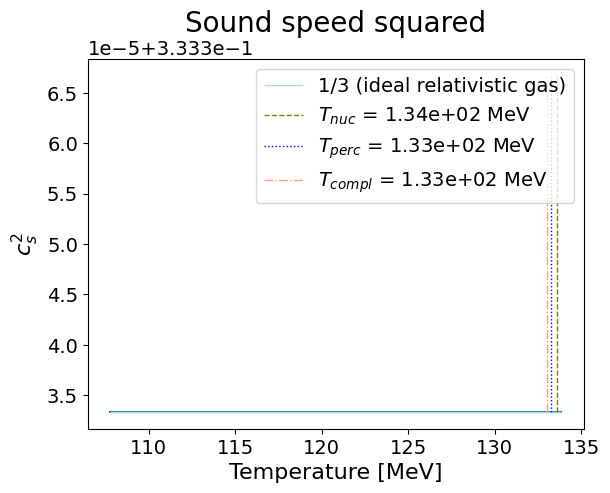

In [116]:
from GWparams import cs2

if T_perc is not None:
    action_over_T(T_perc)
    c_s2 = cs2(T_perc, dp, true_vev, units = units)

y = [cs2(T, dp, true_vev, units = units) for T in Temps]
plt.plot(Temps, y)
plt.hlines(1/3, Temps[0], Temps[-1], color='lightblue', linestyle='-', linewidth=1, label='1/3 (ideal relativistic gas)')
plt.vlines(T_nuc, np.nanmin(y), np.nanmax([np.nanmax(y), (1+1e-4) * 1/3]), color='olive', linestyle='--', linewidth=1, label=f'$T_{{nuc}}$ = {T_nuc:.2e} {units}')
plt.vlines(T_perc, np.nanmin(y), np.nanmax([np.nanmax(y), (1+1e-4) * 1/3]), color='blue', linestyle=':', linewidth=1, label=f'$T_{{perc}}$ = {T_perc:.2e} {units}')
plt.vlines(T_completion, np.nanmin(y), np.nanmax([np.nanmax(y), (1+1e-4) * 1/3]), color='lightsalmon', linestyle='-.', linewidth=1, label=f'$T_{{compl}}$ = {T_completion:.2e} {units}')
plt.title('Sound speed squared')
plt.xlabel(f'Temperature [{units}]')
plt.ylabel('$c_s^2$')
plt.legend()
plt.show()

In [117]:
import numpy as np
from GWparams import alpha_th_bar # This is the definition of \alpha
from custom_model import CustomModel
def c_alpha_inf(T, units):
    v_true = true_vev[T]
    v_false = false_vev[T]
    Dm2_photon = 3 * g**2 * (v_true**2 - v_false**2)
    Dm2_scalar = 3 * lambda_ * (v_true**2 - v_false**2)
    numerator = (Dm2_photon + Dm2_scalar) * T**2 / 24
    rho_tot = - T * 3 * (dp.dVdT(v_false, T, include_radiation=True, include_SM = True, units = units) ) / 4
    rho_DS = - T * 3 * (dp.dVdT(v_false, T, include_radiation=True, include_SM = False, units = units) ) / 4

    # Handle division by zero or negative density
    if rho_tot <= 0:
        alpha_inf_tot = np.nan
    else:
        alpha_inf_tot = numerator / rho_tot

    if rho_DS <= 0:
        alpha_inf_DS = np.nan
    else:
        alpha_inf_DS = numerator / rho_DS

    return alpha_inf_tot, alpha_inf_DS

def c_alpha_eq(T, units):
    v_true = true_vev[T]
    v_false = false_vev[T]
    # The numerator definition is from the original notebook; handle potential division by zero in the denominator.
    numerator = (g**2 * 3 * (g * (v_true - v_false)) * T**3)
    rho_tot = - T * 3 * (dp.dVdT(v_false, T, include_radiation=True, include_SM = True, units = units) ) / 4
    rho_DS = - T * 3 * (dp.dVdT(v_false, T, include_radiation=True, include_SM = False, units = units) ) / 4

    # Handle division by zero or negative density
    if rho_tot <= 0:
        alpha_eq_tot = np.nan
    else:
        alpha_eq_tot = numerator / rho_tot

    if rho_DS <= 0:
        alpha_eq_DS = np.nan
    else:
        alpha_eq_DS = numerator / rho_DS

    return alpha_eq_tot, alpha_eq_DS

In [118]:
import numpy as np
from GWparams import alpha_th_bar # This is the definition of \alpha
from dof_interpolation import g_rho # For g_rho
from utils import convert_units # For convert_units

# Redefine alpha to use thermal energy density for denominator
# Latent heat calculation
DeltaV = dp.DVtot(false_vev[T_perc], T_perc) - V_min_value[T_perc]
dVdT_false = dp.dVdT(false_vev[T_perc], T_perc, include_radiation=False, include_SM=False)
dVdT_true = dp.dVdT(true_vev[T_perc], T_perc, include_radiation=False, include_SM=False)
LatentHeat = DeltaV - T_perc * (dVdT_false - dVdT_true)

# Radiation energy density
rho_radiation = (np.pi**2 / 30.0) * g_rho(T_perc / convert_units[units]) * T_perc**4

# Ensure rho_radiation is not zero or negative
if rho_radiation <= 0:
    alpha = np.nan
else:
    alpha = LatentHeat / rho_radiation

# Recalculate alpha_inf and alpha_eq using the corrected thermal energy density
alphas_inf_nums, alphas_inf_dens = c_alpha_inf(T_perc, units)
alphas_eq_nums, alphas_eq_dens = c_alpha_eq(T_perc, units)


v_true = true_vev[T_perc]
v_false = false_vev[T_perc]

Dm2_photon = 3 * g**2 * (v_true**2 - v_false**2)
Dm2_scalar = 3 * lambda_ * (v_true**2 - v_false**2)
numerator_inf = (Dm2_photon + Dm2_scalar) * T_perc**2 / 24
alpha_inf = numerator_inf / rho_radiation

numerator_eq = (g**2 * 3 * (g * (v_true - v_false)) * T_perc**3)
alpha_eq = numerator_eq / rho_radiation

gamma_eq = (alpha - alpha_inf) / alpha_eq

print(f"alpha = {alpha}")
print(f"alpha_inf = {alpha_inf}")
print(f"alpha_eq = {alpha_eq}")
print(f"gamma_eq = {gamma_eq}")

is_physical = True # Initialize is_physical
if alpha < alpha_inf:
    is_physical = False
    print("\n*** Warning, the bubble expansion is not in runaway regime! The results of the computation are not reliable ***")

v_min = 0.99

if np.isnan(gamma_eq) or gamma_eq < 1 / np.sqrt(1 - v_min**2):
    is_physical = False
    print(f"\n*** Warning, the NLO pressure could prevent the walls to reach relativistic velocities (gamma_eq = {gamma_eq:.2e}). The results of the computation are not reliable ***")

alpha = 0.0011063684432352314
alpha_inf = 0.00038971864042367036
alpha_eq = 0.03436400796422465
gamma_eq = 0.020854662924000136

*** Warning, the NLO pressure could prevent the walls to reach relativistic velocities (gamma_eq = 2.09e-02). The results of the computation are not reliable ***


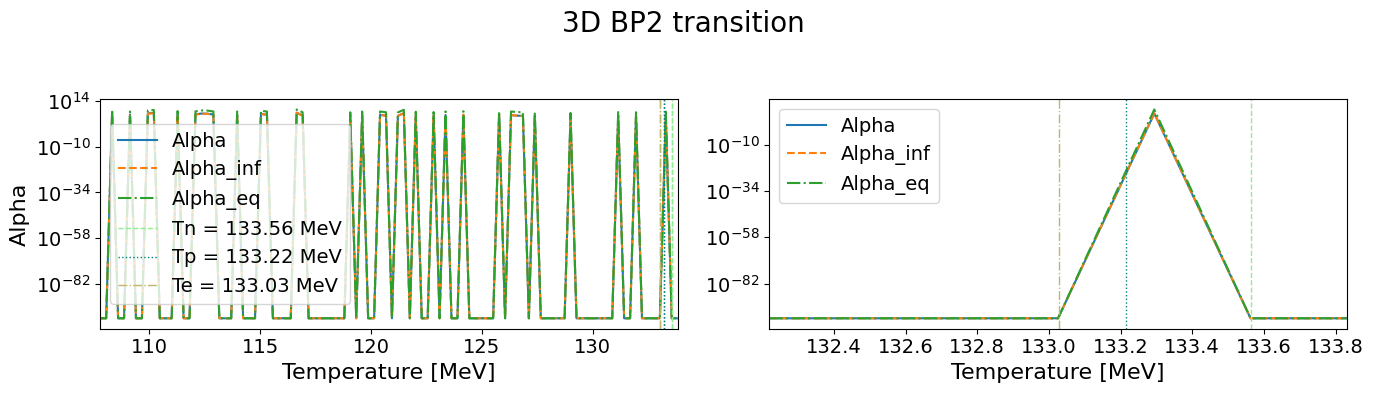

In [119]:
import numpy as np
import matplotlib.pyplot as plt

# Explicitly disable LaTeX rendering to prevent ParseException
plt.rcParams['text.usetex'] = False

# Ensure alpha_T, alpha_inf_T, alpha_eq_T are properly defined
alpha_T = np.array([alpha_th_bar(T, dp, V_min_value, false_vev, true_vev, units)[0] for T in Temps])
alpha_inf_T = np.array([c_alpha_inf(t, units)[0] for t in Temps]) # Corrected indexing
alpha_eq_T = np.array([c_alpha_eq(t, units)[0] for t in Temps]) # Corrected indexing

# Re-create mask to ensure it is consistent with the current Temps length
# This section ensures 'mask' is consistent with 'Temps' when used for indexing.
t_mil_min = np.nanmin([T_completion, T_perc, T_nuc])
t_mil_max = np.nanmax([T_completion, T_perc, T_nuc])

# Handle cases where min/max might be NaN if T_nuc, T_perc, T_completion are all NaN
if np.isnan(t_mil_min) or np.isnan(t_mil_max):
    # If no valid milestones (e.g., all T_nuc, T_perc, T_completion are NaN), use full range
    mask = np.ones_like(Temps, dtype=bool)
else:
    # Ensure indices are within bounds
    i0 = max(int(np.argmin(np.abs(Temps - t_mil_min))) - 3, 0)
    i1 = min(int(np.argmin(np.abs(Temps - t_mil_max))) + 3, len(Temps)-1)
    mask = np.zeros_like(Temps, dtype=bool)
    mask[i0:i1+1] = True

# Define a small positive floor for log plotting, and handle NaN/inf
plot_floor = 1e-100 # A very small positive number
def _log_plot_safe(arr):
    arr = np.asarray(arr, dtype=float)
    arr[np.isnan(arr)] = plot_floor # Replace NaN with floor
    arr[arr <= 0] = plot_floor # Replace non-positive with floor
    arr[np.isinf(arr)] = plot_floor # Replace inf with floor
    return arr

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
axes[0].plot(Temps, _log_plot_safe(alpha_T), linestyle='-', label='Alpha')
axes[0].plot(Temps, _log_plot_safe(alpha_inf_T), linestyle='--', label='Alpha_inf')
axes[0].plot(Temps, _log_plot_safe(alpha_eq_T),  linestyle='-.', label='Alpha_eq')
axes[0].axvline(T_nuc, color='lightgreen', linestyle='--', linewidth=1, label=f'Tn = {T_nuc:.2f} {units}')
axes[0].axvline(T_perc, color='teal', linestyle=':', linewidth=1, label=f'Tp = {T_perc:.2f} {units}')
axes[0].axvline(T_completion, color='darkkhaki', linestyle='-.', linewidth=1, label=f'Te = {T_completion:.2f} {units}')
axes[0].set_xlabel(f"Temperature [{units}]")
axes[0].set_ylabel('Alpha')
axes[0].set_yscale('log')
axes[0].set_xlim(Temps[0], Temps[-1])
axes[0].legend()


axes[1].plot(Temps[mask], _log_plot_safe(alpha_T[mask]), label='Alpha', linestyle='-')
axes[1].plot(Temps[mask], _log_plot_safe(alpha_inf_T[mask]), label='Alpha_inf', linestyle='--')
axes[1].plot(Temps[mask], _log_plot_safe(alpha_eq_T[mask]), label='Alpha_eq', linestyle='-.')
axes[1].set_xlabel(f"Temperature [{units}]")
axes[1].set_xlim(Temps[mask][0], Temps[mask][-1])

y_data_masked = np.concatenate([_log_plot_safe(alpha_T[mask]), _log_plot_safe(alpha_inf_T[mask]), _log_plot_safe(alpha_eq_T[mask])])
y_data_masked_positive = y_data_masked[y_data_masked > plot_floor]

if len(y_data_masked_positive) > 1 and np.nanmax(y_data_masked_positive) > np.nanmin(y_data_masked_positive):
    axes[1].set_yscale('log')
else:
    axes[1].set_yscale('linear')
    axes[1].set_ylim(bottom=0)

axes[1].legend()

for ax in axes.flatten():
    ax.axvline(T_nuc, color='lightgreen', linestyle='--', linewidth=1, label=f'Tn = {T_nuc:.2f} {units}')
    ax.axvline(T_perc, color='teal', linestyle=':', linewidth=1, label=f'Tp = {T_perc:.2f} {units}')
    ax.axvline(T_completion, color='darkkhaki', linestyle='-.', linewidth=1, label=f'Te = {T_completion:.2f} {units}')

fig.suptitle(f'{description} transition', y=1.00)
plt.savefig(figure_dir + f"alpha_{description}.pdf", dpi=300, bbox_inches='tight')
plt.tight_layout()
plt.show()


In [120]:
from temperatures import R_sepH
import numpy as np # Import numpy for np.interp

RH, R = R_sepH(Temps, Gamma, logP_f, H, ratio_V)
# Replace interpolation_narrow with np.interp for linear interpolation
RH_interp = np.interp(T_perc, Temps, RH)
H_star = np.interp(T_perc, Temps, H)
R_star = RH_interp / H_star

print(f"R* H* = {RH_interp:.2e}")

R* H* = 4.69e-13


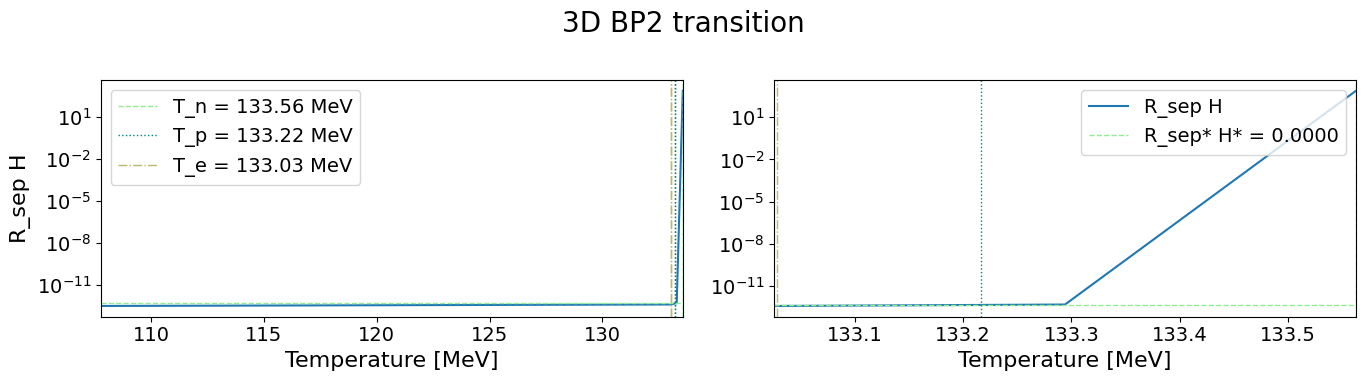

In [121]:
import matplotlib.pyplot as plt
import numpy as np


# Create subplots
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# First plot (full RH plot)
axes[0].plot(Temps, RH)
axes[0].set_ylabel('R_sep H')
axes[0].set_yscale('log')
axes[0].axhline(RH_interp, color='lightgreen', linestyle='--', linewidth=1)
axes[0].axvline(T_nuc, color='lightgreen', linestyle='--', linewidth=1, label=f'T_n = {T_nuc:.2f} {units}')
axes[0].axvline(T_perc, color='teal', linestyle=':', linewidth=1, label=f'T_p = {T_perc:.2f} {units}')
axes[0].axvline(T_completion, color='darkkhaki', linestyle='-.', linewidth=1, label=f'T_e = {T_completion:.2f} {units}')
axes[0].set_xlim(Temps[0], Temps[np.max(np.where(RH < np.inf)[0])])
axes[0].legend()

# Second plot (masked RH plot)
# Re-calculate mask based on milestones to ensure it covers a valid range
t_mil_min_plot = np.nanmin([T_completion, T_perc, T_nuc])
t_mil_max_plot = np.nanmax([T_completion, T_perc, T_nuc])

# Extend the range slightly for better visualization
padding = 0.05 * (t_mil_max_plot - t_mil_min_plot)
if np.isnan(padding):
    # Fallback if milestones are too close or NaN
    padding = 0.05 * (Temps[-1] - Temps[0]) # Use overall range

mask = (Temps >= t_mil_min_plot - padding) & (Temps <= t_mil_max_plot + padding)

# Ensure mask is not empty; if it is, fall back to a default reasonable range or full range
if not np.any(mask) and Temps.size > 0:
    # If the computed mask is still empty, try to ensure at least some points are covered
    center_T = T_perc if np.isfinite(T_perc) else np.mean(Temps)
    range_T = Temps[-1] - Temps[0]
    if range_T == 0: # Handle case of single point or all same temps
        mask = (Temps == center_T)
    else:
        mask = (Temps >= center_T - 0.1 * range_T) & (Temps <= center_T + 0.1 * range_T)
    if not np.any(mask):
        mask = np.ones_like(Temps, dtype=bool) # Fallback to full range if all else fails

# Plot only if the mask selects valid points
if np.any(mask):
    axes[1].plot(Temps[mask], RH[mask], label='R_sep H')
    axes[1].set_yscale('log')
    axes[1].axhline(RH_interp, color='lightgreen', linestyle='--', linewidth=1, label=f'R_sep* H* = {RH_interp:.4f}')
    axes[1].set_xlim(Temps[mask][0], Temps[mask][-1])
    axes[1].legend()
else:
    axes[1].set_title("No data in masked range")

# Add vertical lines to both plots for nucleation, percolation, and completion temperatures
for ax in axes.flatten():
    ax.axvline(T_nuc, color='lightgreen', linestyle='--', linewidth=1, label=f'T_n = {T_nuc:.2e} {units}')
    ax.axvline(T_perc, color='teal', linestyle=':', linewidth=1, label=f'T_p = {T_perc:.2e} {units}')
    ax.axvline(T_completion, color='darkkhaki', linestyle='-.', linewidth=1, label=f'T_e = {T_completion:.2e} {units}')
    ax.set_xlabel(f"Temperature [{units}]")

fig.suptitle(f'{description} transition', y=0.97)

# Save and show the plot
plt.savefig("RH_transition.pdf", dpi=300, bbox_inches='tight')
plt.tight_layout()
plt.show()

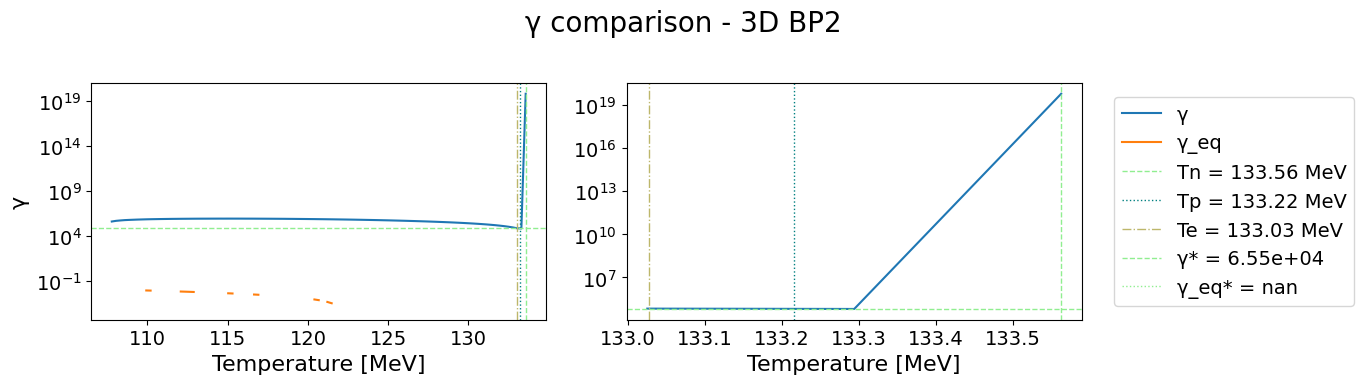

In [122]:
import numpy as np
from temperatures import R0
import matplotlib.pyplot as plt

# Explicitly disable LaTeX rendering
plt.rcParams['text.usetex'] = False

# Ensure numpy is imported for np.interp
r0 = np.array([R0(T, S3overT, V_exit) for T in Temps])

# Extract only the first element from the returned tuples to ensure consistent array shapes
γ_eq_T = (alpha_T - np.array([c_alpha_inf(t, units)[0] for t in Temps])) / np.array([c_alpha_eq(t, units)[0] for t in Temps])
γ = 2 * R / (3 * r0)

γ_star = 2 * R_star / (3 * R0(T_perc, S3overT, V_exit))
γ_eq_star = np.interp(T_perc, Temps, γ_eq_T)  # Fixed: Replaced interpolation_narrow with np.interp

# Create the plot
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Plot γ and γ_eq with plain text labels
axes[0].plot(Temps, γ, label='γ')
axes[0].plot(Temps, γ_eq_T, label='γ_eq')
axes[0].set_yscale('log')
axes[0].set_xlabel(f'Temperature [{units}]')
axes[0].set_ylabel('γ')

# Plot for masked temperatures
axes[1].plot(Temps[mask], γ[mask], label='γ')
axes[1].plot(Temps[mask], γ_eq_T[mask], label='γ_eq')
axes[1].set_yscale('log')
axes[1].set_xlabel(f'Temperature [{units}]')
axes[1].legend()

# Add vertical and horizontal lines for critical temperatures
for ax in axes.flatten():
    ax.axvline(T_nuc, color='lightgreen', linestyle='--', linewidth=1, label=f'Tn = {T_nuc:.2f} {units}')
    ax.axvline(T_perc, color='teal', linestyle=':', linewidth=1, label=f'Tp = {T_perc:.2f} {units}')
    ax.axvline(T_completion, color='darkkhaki', linestyle='-.', linewidth=1, label=f'Te = {T_completion:.2f} {units}')
    ax.axhline(γ_star, color='lightgreen', linestyle='--', linewidth=1, label=f'γ* = {γ_star:.2e}')
    ax.axhline(γ_eq_star, color='lightgreen', linestyle=':', linewidth=1, label=f'γ_eq* = {γ_eq_star:.2e}')

handles, labels = axes[1].get_legend_handles_labels()
axes[1].legend(handles=handles, labels=labels, loc='center left', bbox_to_anchor=(1.05, 0.5))

# Title for the figure
fig.suptitle(f'γ comparison - {description}')
plt.tight_layout()
plt.show()

In [123]:
from GWparams import beta
import temperatures as temp # Import the temperatures module to access compute_logP_f

logP_f, Temps, ratio_V, Gamma, H = temp.compute_logP_f(dp, V_min_value, S3overT, v_w = 1, units = units, cum_method= 'None')

beta_Hn, gamma_Hn, times, Gamma_t, Temps_t, H_t = beta(Temps, ratio_V, Gamma, H, T_nuc, T_perc, verbose = True)

# delta = (T_nuc - T_perc) / 2
# beta_Hn, gamma_Hn, times, Gamma_t, Temps_t, H_t = beta(Temps, ratio_V, Gamma, H, T_perc + delta, T_perc - delta, verbose = True)

print("beta =", beta_Hn)
print("gamma =", gamma_Hn)

beta = 52721.16461318546
gamma = 3326.6080710998804


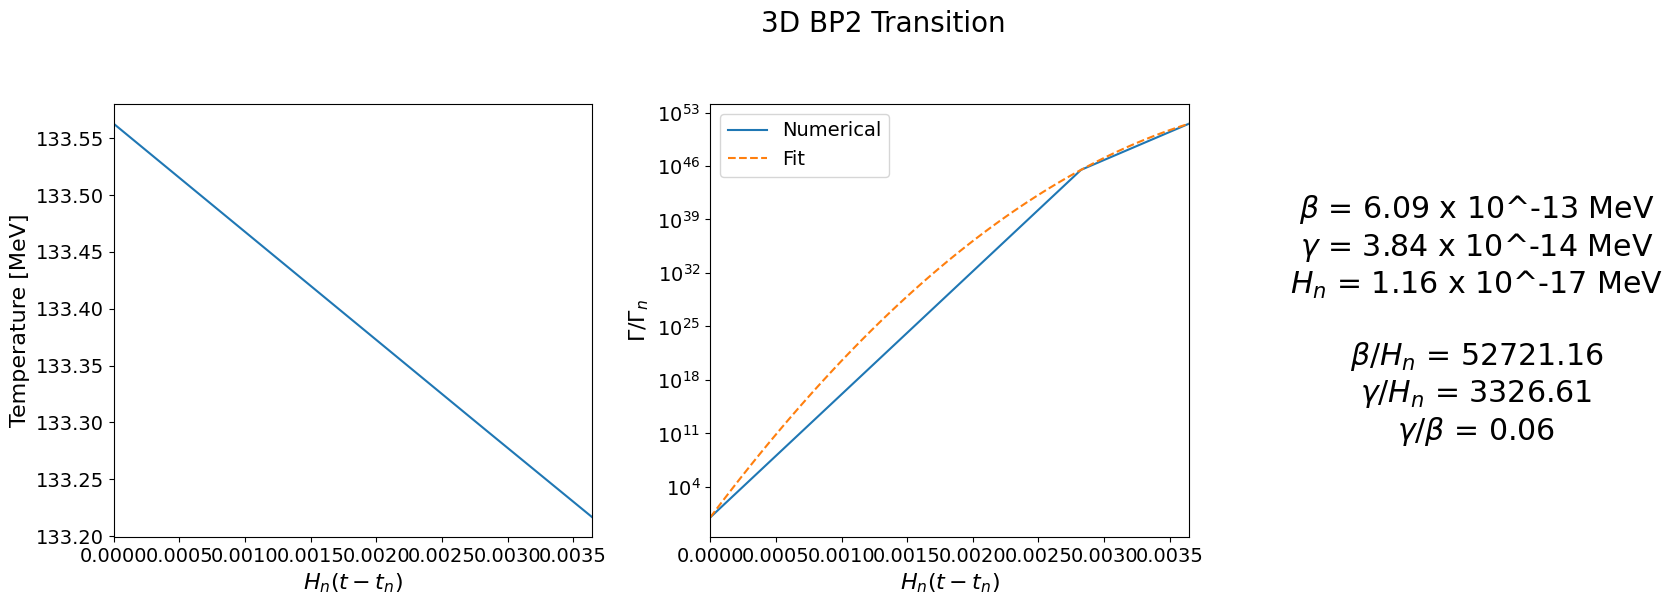

Percolation at 3.65e-03


In [124]:
import numpy as np
import matplotlib.pyplot as plt

# Assuming values for times, Temps_t, Gamma_t, beta_Hn, gamma_Hn, and units are already defined

Gamma_n = Gamma_t[0]
H_n = H_t[0]

def scientific_notation(number):
    """ Return a string formatted in scientific notation with double caret for LaTeX. """
    exponent = int(np.floor(np.log10(abs(number))))
    coefficient = number / 10**exponent
    return f"{coefficient:.2f} x 10^{exponent}"


# Create figure and axes
fig, axes = plt.subplots(1, 2, figsize=(18, 6))

# Plotting the temperature evolution
axes[0].plot(times, Temps_t)
axes[0].set_xlabel(r"$H_n (t - t_n)$")
axes[0].set_ylabel(f"Temperature [{units}]")
axes[0].set_xlim(times[0], times[-1])

# Prepare the text box to display parameter values
box_text = (
    f"$\\beta$ = {scientific_notation(beta_Hn * H_n)} {units}\n"
    f"$\\gamma$ = {scientific_notation(gamma_Hn * H_n)} {units}\n"
    f"$H_n$ = {scientific_notation(H_n)} {units}\n\n"
    f"$\\beta / H_n$ = {beta_Hn:.2f}\n"
    f"$\\gamma / H_n$ = {gamma_Hn:.2f}\n"
    f"$\\gamma / \\beta$ = {gamma_Hn / beta_Hn:.2f}"
)

# Plotting Gamma values and the fit
axes[1].plot(times, Gamma_t / Gamma_t[0], label="Numerical")
tfit = np.linspace(times[0], times[-1], 100, endpoint=True)
axes[1].plot(tfit, np.exp(beta_Hn * tfit - (gamma_Hn * tfit) ** 2 / 2), label="Fit", linestyle='--')
axes[1].set_xlabel(r"$H_n (t - t_n)$")
axes[1].set_ylabel(r"$\Gamma / \Gamma_n$")
axes[1].set_yscale('log')
axes[1].set_xlim(times[0], times[-1])

# Adding the parameter box on the plot using $$ for LaTeX-friendly format
axes[1].text(1.6, 0.5, box_text,       # coordinates (0-1 for normalized)
             fontsize='large',
             transform=axes[1].transAxes,  # use normalized coordinates
             horizontalalignment='center', # center text horizontally
             verticalalignment='center')   # center text vertically

axes[1].legend()

# Title and layout
plt.suptitle(f'{description} Transition', y=1.02)
plt.tight_layout()

# Saving the figure to a file
plt.savefig(figure_dir + f"nucleation_{description}.pdf", dpi=300, bbox_inches='tight')
plt.show()

print(f"Percolation at {times[-1]:.2e}")


In [125]:
from google.colab import files

uploaded = files.upload()

Saving NG15.pkl to NG15 (2).pkl


In [126]:
import matplotlib.pyplot as plt

plt.ion()          # re-enable interactive plotting
plt.close("all")   # clean broken figures


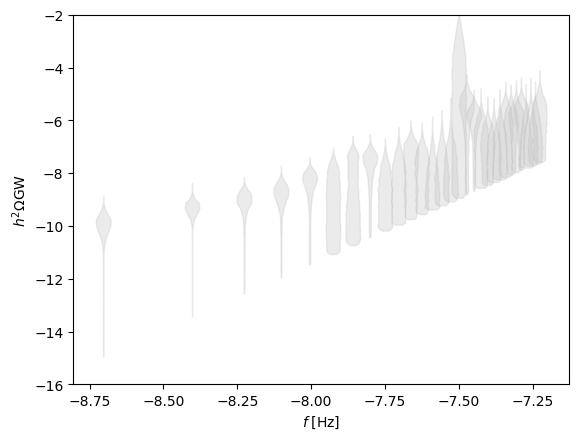

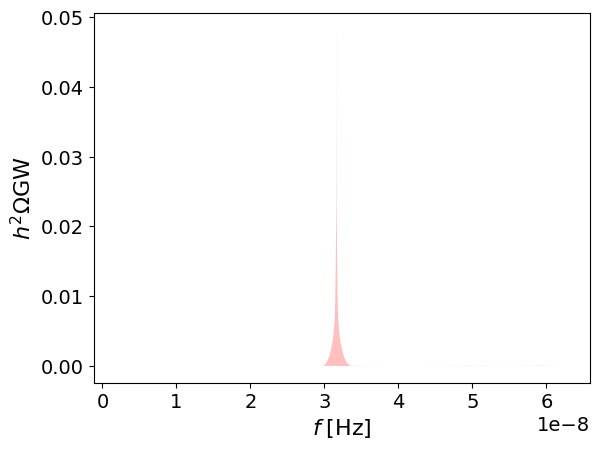

In [127]:
import pickle
import numpy as np
import matplotlib.pyplot as plt
import warnings

warnings.filterwarnings("ignore")
pkl_path = "NG15.pkl"

with open(pkl_path, "rb") as f:
    fig, ax = pickle.load(f)

fig_linear, ax_linear = plt.subplots(figsize=fig.get_size_inches())

for collection in ax.collections:
    if hasattr(collection, "get_paths") and len(collection.get_paths()) > 0:
        path = collection.get_paths()[0]
        vertices = path.vertices

        if len(vertices) > 0:
            x_log = vertices[:, 0]
            y_log = vertices[:, 1]

            x_linear = 10**x_log
            y_linear = 10**y_log

            ax_linear.fill(
                x_linear,
                y_linear,
                facecolor="red",        # <-- force red
                edgecolor="none",       # cleaner for papers
                alpha=0.25,             # good transparency
            )

ax_linear.set_xscale("linear")
ax_linear.set_yscale("linear")
ax_linear.set_xlabel(ax.get_xlabel())
ax_linear.set_ylabel(ax.get_ylabel())
ax_linear.set_title(ax.get_title())

plt.show()


In [128]:
x=(alpha+1)**(1/4)

In [129]:
T_reh=x*T_perc

Is physical? False
lambda = 0.006
g = 0.75002
vev = 500.0 MeV
m_phi = 54.772255750516614 MeV
m_Z = 375.01 MeV
T_crit = 134.09999999999997 MeV
T_nuc = 133.56281982453493 MeV
T_perc = 133.21633861136002 MeV
T_completion = 133.02832554994725 MeV
T_min = 107.50958131448104 MeV
T_reh = 133.25316992229588 MeV
Minimal value of P_f = 0.0
alpha = 0.0011063684432352314, alpha_inf = 0.00038971864042367036, alpha_eq = 0.03436400796422465
gamma_* = 65489.142030537005, gamma_eq = 0.020854662924000136
Is runaway? True
RH = 4.689945124545602e-13


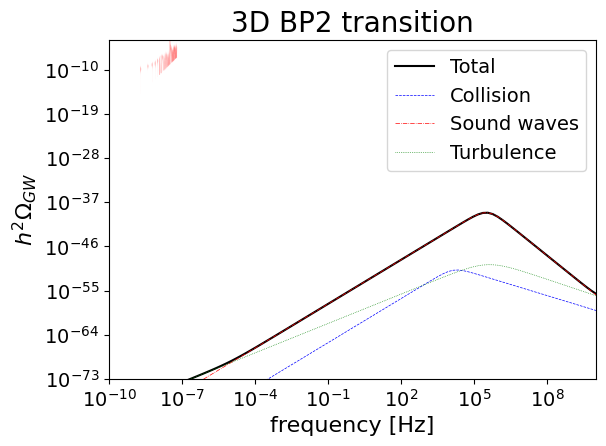

In [130]:
import pickle
from GWparams import GW_SuperCooled
import contextlib
import os # Import the os module

def print_params():
    print(f"Is physical? {is_physical}")
    print(f"lambda = {lambda_}")
    print(f"g = {g}")
    print(f"vev = {vev} {units}")
    print(f"m_phi = {np.sqrt(2*lambda_)*vev} {units}")
    print(f"m_Z = {g*vev} {units}")
    print(f"T_crit = {T_max} {units}")
    print(f"T_nuc = {T_nuc} {units}")
    print(f"T_perc = {T_perc} {units}")
    print(f"T_completion = {T_completion} {units}")
    print(f"T_min = {T_min} {units}")
    print(f"T_reh = {T_reh} {units}")
    print(f"Minimal value of P_f = {np.nanmin(np.exp(logP_f))}")
    print(f"alpha = {alpha}, alpha_inf = {alpha_inf}, alpha_eq = {alpha_eq}")
    print(f"gamma_* = {γ_star}, gamma_eq = {gamma_eq}")
    print(f"Is runaway? {alpha > alpha_inf}")
    print(f"RH = {R_star * H_star}")
    #print(f"beta/H_n = {beta_H0}, gamma/H_n = {gamma_H0}, gamma/beta = {gamma_H0/beta_H0}")

# Ensure the figure directory exists (already done in other cells, but good practice)
os.makedirs(figure_dir, exist_ok=True)

# Save the relevant reults to a file
with open(os.path.join(figure_dir, f'{description}.txt'), 'w') as f:
    with contextlib.redirect_stdout(f):
        print_params()

log_freq_min = -10
log_freq_max = 10

if T_perc is not None:
    inst = GW_SuperCooled(T_perc, alpha, alpha_inf, alpha_eq, R_star, γ_star, H_star, c_s = np.sqrt(c_s2), units = units)
    print_params()

    x = np.linspace(log_freq_min, log_freq_max, 100)
    x = 10**x
    ax_linear.plot(x, inst.Omegah2(x), label = "Total", color='black')
    ax_linear.plot(x, inst.Omegah2coll(x), label = "Collision", linewidth=0.5, color='blue', linestyle='--')
    ax_linear.plot(x, inst.Omegah2sw(x), label = "Sound waves", linewidth=0.5, color='red', linestyle='-.')
    ax_linear.plot(x, inst.Omegah2turb(x), label = "Turbulence", linewidth=0.5, color='green', linestyle=':')
    ax_linear.set_xlim(x[0], x[-1])
    ax_linear.set_ylim(1e-73, 1e-4)
    ax_linear.set_xscale('log')
    ax_linear.set_yscale('log')
    ax_linear.set_xlabel('frequency [Hz]')
    ax_linear.set_ylabel('$h^2 \Omega_{GW}$')
    #plt.title(f'GW spectrum - {description}')
    ax_linear.legend()
    ax_linear.set_title(f'{description} transition', y=1)
    fig_linear.savefig(figure_dir + f"GW_{description}.pdf", dpi=300, bbox_inches='tight')
    fig_linear.tight_layout()

# Save the for spectrum future plotting
if is_physical:
    with open(os.path.join(figure_dir, f'GW_{description}.pkl'), 'wb') as f: # Use os.path.join here as well
        pickle.dump(inst, f)

fig_linear